 # How to Run
1. Begin by setting the granularity to 'q'. (change the accessed element in the list to 0)
2. Set run_every_query to True
3. Update max_quarter and max_month
4. Run All
5. Set the granularity to 'm'. (change the accessed element in the list to 1)
6. Set run_every_query to False and build_ms_df_from_scratch to True
7. Restart Kernel and Run All

In [2]:
import pandas as pd
import numpy as np
import pyodbc
import pickle
import warnings
import time
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
tqdm.pandas()
pd.set_option('display.max_columns', 100)
pd.set_option('display.min_rows', 100)
import openpyxl
import datetime as dt
import re
import os
import copy
#git comment test

In [3]:
granularity = ['q', 'm','w'][0]
run_every_query = True
max_quarter, max_month = 1, 1
max_week = dt.date.today().strftime("%U")
max_week = int(max_week)

In [4]:
def vintage_to_float(vintage):
    """
    Converts a vintage of form 'YYYY QQ' (i.e. '2016 Q2') to a float (i.e. 2016.25)
    The vectorized form of this function for a Series is: pd.to_numeric(df.vintage.str[:4]) + (pd.to_numeric(df.vintage.str[-1]) - 1) / 4
    NOTE: The following formula has been modified to allow for vintages of the form 'YYYY MMM' (i.e. '2016 M06')
    """
    if vintage[5]=='Q':
        return int(vintage[:4]) + (int(vintage[-1]) - 1) / 4
    elif vintage[5]=='M':
        return int(vintage[:4]) + (int(vintage[-2:]) - 1) / 12
    

def float_to_vintage(vintage_float):
    """
    Converts a vintage as a float (i.e. 2016.25) to a str of form 'YYYY QQ' (i.e. '2016 Q2')
    The vectorized form of this function for a Series is: 
        df.vintage_float.astype(int).astype(str) + ' Q' + ((df.vintage_float % 1) * 4 + 1).astype(int).astype(str)
    """
    return str(int(vintage_float)) + ' Q' + str(int((vintage_float % 1) * 4 + 1))
    
"""
SQL and Files
"""
def run_sql(filename, sub_list=[], connection=None, filename_is_query=False):
    """
    Run a SQL Query by reading from a .txt file, substituting values when required.
    Input:
    filename (str): File that we want to read. Usually a .txt file.
    sub_list (list of (str,str) tuples): Substitute each instance of the first element of the tuple for the second.
                                         Example: [('{max_mob}', '6')]
    """
    if filename_is_query:
        query = filename
    else:
        with open(filename, 'r') as file:
            query = file.read()
    for sub in sub_list:
        text, var = sub
        query = query.replace(text, var)
#     print(query)
    if connection is None:
        with pyodbc.connect("DSN=Redshift_prod_new") as conn:
            warnings.filterwarnings("ignore", category=UserWarning)
            df = pd.read_sql_query(sql=query, con=conn)
            warnings.filterwarnings("default", category=UserWarning)
            return df
    else:
        warnings.filterwarnings("ignore", category=UserWarning)
        df = pd.read_sql_query(sql=query, con=connection)
        warnings.filterwarnings("default", category=UserWarning)
        return df

def store_pickle(data, filename):
    """
    Stores a pickle of the given data at the given filename, in a simplified function call
    """
    # Perform a swap if I got the order of data and filename backwards
    if type(data)==str:
        temp = filename
        filename = data
        data = temp
    with open(filename, 'wb') as file:
        pickle.dump(data, file)

def get_pickle(filename):
    """
    Loads a pickle in a simplified function call
    """
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    return data

def smooth(series):
    """
    Calculates a centered average by averaging the previous two values and following two values, as well as the current value.
    Handles the first and last two values separately.
    """
    averaged_series = pd.Series(index=series.index, dtype=float)  # Create an empty Series to store the averaged values
    
    # Handle the first value separately
    averaged_series.iloc[0] = series.iloc[0]
    averaged_series.iloc[1] = (series.iloc[0] + series.iloc[1] + series.iloc[2]) / 3
    
    # Calculate the running average for the middle values
    for i in range(2, len(series) - 2):
        averaged_series.iloc[i] = (series.iloc[i-2] + series.iloc[i-1] + series.iloc[i] + series.iloc[i+1] + series.iloc[i+2]) / 5
    
    # Handle the last value separately
    averaged_series.iloc[-1] = series.iloc[-1]
    averaged_series.iloc[-2] = (series.iloc[-1] + series.iloc[-2] + series.iloc[-3]) / 3
    
    return averaged_series
def weight_by_proceeds(metric, proceeds):
    """
    Function to get the average of a given Series, weighted by Amount Financed.
    """
    return (metric * proceeds).sum() / proceeds.sum()
def weighted_average_and_sum(group, metrics):
    """
    Function that gets the weighted average of a Series (or several series), 
        returning the averages and the sum of Amount Financed.
    """
    if type(metrics)==str:
        weighted_avg = (group[metrics] * group.amt_financed).sum() / group.amt_financed.sum()
        return pd.Series({metrics: weighted_avg, 'amt_financed': group.amt_financed.sum()})
    result_dict = {'amt_financed': group.amt_financed.sum()}
    for metric in metrics:
        weighted_avg = (group[metric] * group.amt_financed).sum() / group.amt_financed.sum()
        result_dict[metric] = weighted_avg.sum()
    return pd.Series(result_dict)

# Old Recovery Model

In [5]:
def auc_pred(rra_df, leave_out, rra_lob_df=None):
    """
    Recovery model used by the pricing team to determine the expected recovery of a vehicle when it is sold.
    KMX uses a different recovery model, so it's handled separately.
    This function was made to support "Leave Out" analysis, which isn't included in the Ragu jar. 
        That's what all the if/else statements are for.
    This function has been vectorized as much as possible, but it's possibly not totally optimized.
    Inputs:
        rra_df (pd.DataFrame object): Data containing vehicle info. Each row is a vehicle, and each row is analyzed separately.
        leave_out (str): Factor to not consider in this runthrough. Helps us understand how much of a role each factor plays.
        rra_lob_df (pd.DataFrame): Only used in Leave Out analysis. Contains every vehicle for every vintage for this LOB.
    Outputs:
        recovery_multiplier (pd.Series): Column to add to rra_df containing the % of original vehicle value we expect to recover.
    """
    if len(rra_df[rra_df.lob=='KMX']) > 0:
        conditions = [
            (rra_df.car_age_orig < 3),
            (rra_df.car_age_orig == 3) & (rra_df.sale_price < 30000),
            (rra_df.car_age_orig == 3) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (rra_df.car_age_orig == 3) & (rra_df.sale_price >= 40000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (rra_df.sale_price < 30000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (3 < rra_df.car_age_orig) & (rra_df.car_age_orig < 6) & (rra_df.sale_price >= 40000),
            (rra_df.car_age_orig >= 6) & (rra_df.sale_price < 30000),
            (rra_df.car_age_orig >= 6) & (30000 <= rra_df.sale_price) & (rra_df.sale_price < 40000),
            (rra_df.car_age_orig >= 6) & (rra_df.sale_price >= 40000)
        ]

        values = [3300, 3700, 5400, 7200, 4700, 6400, 8200, 5700, 7400, 9200]

        recovery_amount = np.maximum(0, rra_df.sale_price - np.select(conditions, values, default=0))

        return recovery_amount * (1 - 0.206) ** rra_df.yob / rra_df.sale_price


    rra_df['coef_intercept'] = 0.0891185245
    rra_df['coef_yob'] = -0.2668087106 * rra_df.yob


    if leave_out != 'Mileage/age':
        rra_df['coef_mlg_x_age'] = 0.0001463508 * rra_df.car_age_orig * rra_df.mileage - 0.0004310013 * rra_df.car_age_orig - 0.0033127224 * rra_df.mileage
    else: 
        rra_df['coef_mlg_x_age'] = np.log((np.exp(0.0001463508 * rra_lob_df.car_age_orig * rra_lob_df.mileage) * np.exp(-0.0004310013 * rra_lob_df.car_age_orig) * np.exp(-0.0033127224 * rra_lob_df.mileage)).mean())
    if leave_out != 'Japanese':
        rra_df['coef_japanese'] = rra_df.car_japanese.map({'Japanese': 0.1004702010, 'Other': 0})
    else:
        rra_df['coef_japanese'] = np.log(rra_lob_df.car_japanese.map({'Japanese': np.exp(0.1004702010), 'Other': np.exp(0)}).mean())
    if leave_out != 'Vehicle class':
        rra_df['coef_class'] = rra_df.car_class_only.map({'Compact': 0.0303893787,
                                        'Minivan': np.log(0.975),
                                        'Sporty': 0.0758593720,
                                        'SUV Large': -0.0237364286,
                                        'SUV Small': 0.0190370746,
                                        'Work Van': 0,
                                        'Truck': 0.1436074633,
                                        'Car': 0, 'Other':0})
    else:
        rra_df['coef_class'] = np.log(rra_lob_df.car_class_only.map({'Compact': np.exp(0.0303893787),
                                                             'Minivan': np.exp(np.log(0.975)),
                                                             'Sporty': np.exp(0.0758593720),
                                                             'SUV Large': np.exp(-0.0237364286),
                                                             'SUV Small': np.exp(0.0190370746),
                                                             'Work Van': np.exp(0),
                                                             'Truck': np.exp(0.1436074633),
                                                             'Car': np.exp(0), 'Other':np.exp(0)}).mean())
    if leave_out != 'Fuel type':
        rra_df['coef_fuel'] = rra_df.fuel_type.map({'Hybrid': -0.0315481529,
                                       'Flex': 0.0255682747,
                                       'Diesel': -0.1284314925,
                                       'EV': np.log(0.9),
                                       'Gas': 0})
    else:
        rra_df['coef_fuel'] = np.log(rra_lob_df.fuel_type.map({'Hybrid': np.exp(-0.0315481529),
                                                    'Flex': np.exp(0.0255682747),
                                                    'Diesel': np.exp(-0.1284314925),
                                                    'EV': np.exp(np.log(0.9)),
                                                    'Gas': np.exp(0)}).mean())
    if leave_out != 'Luxury classification':
        rra_df['coef_lux'] = rra_df.car_lux.map({'Luxury': -0.1108317813, 'Standard': 0})
    else:
        rra_df['coef_lux'] = np.log(rra_lob_df.car_lux.map({'Luxury': np.exp(-0.1108317813), 'Standard': np.exp(0)}).mean())
    if leave_out != 'LOB':
        rra_df['coef_lob'] = rra_df.lob.map({'ENT': 0.0405731662,
                                      'FLD': 0.0405731662,
                                      'FRN': -0.0277901296,
                                      'STG': 0.0263749504,
                                      'AN': 0})
    else:
        rra_df['coef_lob'] = np.log(rra_lob_df.lob.map({'ENT': np.exp(0.0405731662),
                                              'FLD': np.exp(0.0405731662),
                                              'FRN': np.exp(-0.0277901296),
                                              'STG': np.exp(0.0263749504),
                                              'AN': np.exp(0)}).mean())
    if leave_out != 'Driver flag':
        rra_df['coef_driver'] = (-0.0918049638) * rra_df.driver_flag
    else:
        rra_df['coef_driver'] = np.log(rra_lob_df.driver_flag.map({1:np.exp(-0.0918049638), 0: np.exp(0)}).mean())
    if leave_out != 'Impound probability':
        rra_df['coef_impound'] = (-0.2803330880) * rra_df.impound_prob
    else:
        rra_df['coef_impound'] = np.log(np.mean(np.exp((-0.2803330880) * rra_lob_df.impound_prob)))
    
    try:
        # code that may raise an exception

        rra_df=rra_df.dropna()
        for col in ['coef_intercept', 'coef_yob', 'coef_mlg_x_age', 'coef_japanese', 'coef_class', 'coef_fuel', 'coef_lux', 
                    'coef_lux', 'coef_lob', 'coef_driver', 'coef_impound']:
            print(col)
            assert len(rra_df)==len(rra_df.dropna(subset=col))
    except Exception as e:
        # code to handle the exception
        print(col, ';', rra_df.fuel_type.unique())
        print(len(rra_df) - len(rra_df.fuel_type.dropna()))
        print(rra_df)
        store_pickle('rra_df_pickle_exception',rra_df)
        raise Exception()

    return rra_df.r_mmi * np.exp(rra_df.coef_intercept + rra_df.coef_yob + rra_df.coef_mlg_x_age + rra_df.coef_japanese\
                                 + rra_df.coef_class + rra_df.coef_fuel + rra_df.coef_lux + rra_df.coef_lob\
                                 + rra_df.coef_impound + rra_df.coef_driver)

In [6]:
def get_ula_multiplier_nonkmx(ula_df, leave_out):

    ula_df['loss_multiplier'] = 1


    print(ula_df.loss_multiplier.mean())


    if leave_out !='Previous ACA chargeoff':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.prev_co_flag # loss_adj_01_acaco: 1 or 1.1

    print("Previous ACA chargeoff: " + str(ula_df.prev_co_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='Small amount financed':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.small_amt_financed_flag *(1- ula_df.pricing_change_flag) # loss_adj_02_small_amtfin: 1 or 1.1

    print("small atf: " + str(ula_df.small_amt_financed_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='Zero cash down':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.zero_cash_down_flag * (1 - ula_df.pricing_change_flag) # loss_adj_03_zero_down: 1 or 1.1

    print("zero cd: " + str(ula_df.zero_cash_down_flag.mean()))
    print(ula_df.loss_multiplier.mean())



    if leave_out!='High mileage vehicle':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_mileage_vehicle_flag # loss_adj_04_high_mileage: 1 or 1.1


    print("high miles: " + str(ula_df.high_mileage_vehicle_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='High PTI':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_pti_flag * (1 - ula_df.pricing_change_flag) # loss_adj_05_high_PTI: 1 or 1.1


    print("high pti: " + str(ula_df.high_mileage_vehicle_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='Car make':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.car_make_penalty_flag\
                                    - 0.1 * ula_df.car_make_benefit_flag - 0.1*ula_df.pricing_change_flag*ula_df.car_make_benefit_flag
                                    #+  0.1*ula_df.pricing_change_flag*ula_df.car_make_benefit_flag*ula_df.ent_fld_flag # loss_adj_06_vehicle_make: 1 or 0.9 or 1.1

    print("toyho: " + str(ula_df.car_make_benefit_flag.mean()))
    print(ula_df.loss_multiplier.mean())

    if leave_out!='Theft risk':
        ula_df.loss_multiplier *= 0.987 + 0.099 * ula_df.theft_risk_flag * (1-ula_df.pricing_change_flag) + 0.013*ula_df.pricing_change_flag  # loss_adj_09_theft_risk: 0.987 or 1.086

    print("theft risk: " + str(ula_df.theft_risk_flag.mean()))
    print(ula_df.loss_multiplier.mean())

    if leave_out!='MCY high model score, low mileage':
        ula_df.loss_multiplier *= 1 - 0.2 * ula_df.mcy_low_mileage_flag # loss_adj_07_new_MCY: 1 or 0.8
    if leave_out!='Weekday/weekend decision':
        ula_df.loss_multiplier *= 1 - 0.05 * ula_df.weekend_flag\
                                    + 0.02 * ula_df.weekday_flag # loss_adj_08_day_of_week: 1 or 0.95 or 1.02

    #
    #
    # print(ula_df.loss_multiplier)
    # print("pre everything")


         # MS - 130 for all LOB's except ENT where it's MS - 128
    if leave_out!='Student Loans':
        ula_df.loss_multiplier *= 1 + (0.1 * ula_df.student_loan_flag \
                                            - np.minimum( np.maximum( (ula_df.cd_model_score - (130 - 2 * ula_df.ent_flag)) * 0.006, 0 ), 0.03) * (1 - ula_df.student_loan_flag))*(ula_df.student_loans_cutoff_date)




    #
    # print(ula_df.loss_multiplier)
    # print("student loans")

    if leave_out != 'Low PTI':
        # print(ula_df.loss_multiplier)
        ula_df.loss_multiplier *= 1 + (-0.03 * np.minimum(ula_df.cd_model_score, 135) + 3.9) * ula_df.low_pti_flag



    if leave_out!='Secured credit (Chime, etc.)':
        ula_df.loss_multiplier *= 0.966 + 0.273 * ula_df.nonkmx_chime_flag
        #ula_df.loss_multiplier *= 0.989 + 0.111 * ula_df.secured_credit_flag # loss_adj_10_secured_card: 0.989 or 1.1

    print("chime")
    print(ula_df.loss_multiplier.mean())

    print("chime counts: " + str(ula_df.nonkmx_chime_flag.count()))
    print("chime avg: " + str(ula_df.nonkmx_chime_flag.mean()))
    print(ula_df.loss_multiplier.mean())


    if leave_out!='Employment type':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.seasonal_employment_flag\
                                    - 0.1 * ula_df.waiter_employment_flag # loss_adj_11_employment: 1 + 0.1 * cust_attr$employment_flag
    if leave_out!='Authorized tradelines':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.nonkmx_auth_tradelines_flag # loss_adj_13_authorized_tradeline: 1 or 1.1


    if leave_out != 'Fraud':
        ula_df.loss_multiplier *= 1  + (ula_df.fraud_adjustment -1)



    if leave_out != 'Driver flag':
        ula_df.loss_multiplier *= 1 + 0.15 * ula_df.driver_flag



    if leave_out!='Clip':
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.8, 2) #previously (0.8,1.2)
    #if leave_out!='Null FICO with Vantage':
        #ula_df.loc[ula_df['fico_adjustment_flag'] == 1, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag # loss_adj_14_non_fico: 0.99 or 1.1
    if leave_out!='Dealer Level (Non-KMX)':
        ula_df.loss_multiplier *= ula_df.pricing_scalar
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.7, 1.4) #previously (0.8,1.2)
    # if leave_out!='Dealer Level (Non-KMX)':
    #     ula_df.loss_multiplier *= 1 - 0.2 * (ula_df.lob_or_bucket == 'A').astype(int) \
    #                                 - 0.1 * (ula_df.lob_or_bucket == 'B').astype(int) \
    #                                 + 0.09 * (ula_df.lob_or_bucket == 'D').astype(int) \
    #                                 + 0.2 * (ula_df.lob_or_bucket == 'E').astype(int)
        #change for lob dll ragu
    # The following is a pricing adjustment, but we don't include it, since it's macroeconimic (that's what the loss committee predicts)
#       #Additional loss adjustment to ensure losses match loss committe predictions
#   lob_scalar <- ifelse(app_attr$lob == "AN", 1.045,
#                        ifelse(app_attr$lob == "FLD", 1.09,
#                               ifelse(app_attr$lob == "FRN", 0.925,
#                                      ifelse(app_attr$lob == "STG", 0.996, 1))))



    return ula_df

In [7]:
def get_ula_multiplier_kmx(ula_df, loss_scale=0.067, leave_out='None'):
    ula_df['loss_multiplier'] = 1




    # if leave_out!='Job time':
    #     # 0.99 counter
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag

    if leave_out!='Low FICO':
        # remove
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_fico_flag & ~ula_df.high_model_score_flag)\
                                    + loss_scale * (ula_df.low_fico_flag & ula_df.high_model_score_flag)


    if leave_out!='Low Vantage':

        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_vantage_flag & ~ula_df.high_model_score_flag)\
                                    + loss_scale * (ula_df.low_vantage_flag & ula_df.high_model_score_flag)

    # if leave_out!='Louisiana':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.35 * ula_df.louisiana_flag

    if leave_out!='High PTI':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0 * ula_df.normal_pti_flag \
                                    + 0.05 * ula_df.high_pti_tier_1_flag \
                                    + 0.1 * ula_df.high_pti_tier_2_flag \
                                    + (1.4 * (1 + loss_scale) - 1) * ula_df.high_pti_tier_3_flag
   
   
   
    # if leave_out!='Existing DQ':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.1 * ula_df.existing_dq_flag
    # if leave_out!='Employment type':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag
    ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] /= (1 + loss_scale)



    if leave_out!='Secured credit (Chime, etc.)':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + (-0.01 + 0.06 * ula_df.secured_credit_flag)\
                                        * ~(~ula_df.job_time_flag & ula_df.narrowed_soft_pull_flag & ula_df.secured_credit_flag)

    if leave_out!='Authorized tradelines':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 0.99 + 0.18 * ula_df.kmx_auth_tradelines_flag
   
   
    # if leave_out!='Null FICO with Vantage':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag + 0.01 * ula_df.null_fico_null_vantage_flag
    
    
    if leave_out!='Soft pull':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + ~ula_df.job_time_flag * (~ula_df.narrowed_soft_pull_flag * -0.025
                                                               + ula_df.narrowed_soft_pull_flag * (~ula_df.secured_credit_flag * 0.108
                                                                                                   + ula_df.secured_credit_flag * 0.295))

    if leave_out != 'Fraud':
        # print("bef", ula_df.loss_multiplier)
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + (ula_df.fraud_adjustment - 1)
        # print("aft", ula_df.loss_multiplier)
        # print("fraud", ula_df.fraud_adjustment)


    if leave_out!='Clip': #verified
        clipped_multiplier = np.clip(ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'], 0.8, 1.35 / (1 + loss_scale))

        ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'] = clipped_multiplier


        # clipped_multiplier = np.clip(ula_df[~ula_df.high_pti_tier_3_flag].loss_multiplier, 0.8, 1.35 / (1 + loss_scale))
        #
        # ula_df.loc[~ula_df.high_pti_tier_3_flag & ~ula_df.mtn_3_1_flag , 'loss_multiplier'] = clipped_multiplier






    if leave_out!='Vehicle Age':
        ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier']  *= 0.8593 + 0.0201 * ula_df.continuous_vehicle_age


    #Mountain 3.1 Gross Loss Adjustments
    # MTN 3.2 is exactly the same as 3.1


    # add low vantage to 3.1: vantage 5-475, if soft pull then 1.1x counter 0.99, no soft pull 1.2x v 0.98, NA no adjustment

    # 3.1: cash down % penalty:
    # add npc flag, every loan using npc, if pti > 0.2 then penalty is 1.1x and 0.99
    # student loans: if pb or cb has student stu loans, 1.1x and 0.96 counter
    #driver flag, 1.15x no counter, use same determination as nonkmx





    #4.1 has adjustment for >30k sales price. 1.15,  counter is 0.97
    #everything in 3.1 is also in 4.1 + the sales price


    if leave_out !='npc':
        ula_df.loc[ula_df.kmx_npc_flag, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.high_pti_npc




    if leave_out != 'Student Loans':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.96 +  0.14 * ula_df.student_loan_flag




    if leave_out != 'high sales price':
        ula_df.loc[ula_df.mtn_model.isin([4.1]),'loss_multiplier'] *= 0.98 + 0.22 * ula_df.high_sales_price_flag


    if leave_out != 'Driver flag':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + 0.15 * ula_df.driver_flag






    if leave_out!='Louisiana':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier']  *= 1 + 0.35 * ula_df.louisiana_flag
        # print(in )

    if leave_out!='georgia':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier']  *= 1 + 0.1 * ula_df.georgia_flag

    if leave_out!='txca':
        # MS > 140 get 0.9 benefit, 135-140 get 0.95 benefit
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score > 140) ,'loss_multiplier']  *= 1 - 0.1 * ula_df.txca_flag
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score <= 140) &  (ula_df.cd_model_score >= 135)   ,'loss_multiplier']  *= 1 - 0.05 * ula_df.txca_flag


    if leave_out!='state_counter_adj':
        ula_df.loc[ ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1])  & (ula_df.cd_model_score < 150) & ~(ula_df.louisiana_flag | ula_df.georgia_flag | ula_df.txca_flag) ,'loss_multiplier'] *= 1.012
    
    
    if leave_out!='Secured credit (Chime, etc.)': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.96 + (0.01 * ula_df.soft_pull_flag  - 0.18*ula_df.chime_flag* ula_df.soft_pull_flag) + 0.46*ula_df.chime_flag

    if leave_out!='Job time': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag

    if leave_out!='Existing DQ': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.99 + 0.11 * ula_df.existing_dq_flag

    if leave_out!='Employment type': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag





    if leave_out!='Authorized tradelines': #verified
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]),'loss_multiplier'] *= 0.99 + 0.06 * ula_df.kmx_auth_tradelines_flag




    if leave_out!='Soft pull': #verified

        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ula_df.soft_pull_flag,'loss_multiplier'] *= 1.1  * (0.99 + 0.11*ula_df.low_bureau_flag) * (0.97 + 0.15*ula_df.cd_perc_flag) * (0.978 + 0.172*ula_df.open_tl_flag)
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ~ula_df.soft_pull_flag,'loss_multiplier'] *= (1 * (0.98 + 0.22*ula_df.low_bureau_flag)* (0.954 + 0.346*ula_df.cd_perc_flag)  * (0.945 + 0.405*ula_df.open_tl_flag ) /np.maximum(ula_df.cd_perc_flag*ula_df.open_tl_flag*1.2,1)) #verified


                                                                                                          # verified
 #verified
  



    # if leave_out!='Soft pull':
    #     ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ula_df.soft_pull_flag,'loss_multiplier'] *= 1.1 * (0.97 + 0.23*ula_df.secured_credit_flag) * (0.995 + 0.03*ula_df.low_bureau_flag) * (0.97 + 0.15*ula_df.cd_perc_flag) * (0.978 + 0.172*ula_df.open_tl_flag)
    #     ula_df.loc[ula_df.mtn_3_1_flag & ~ula_df.soft_pull_flag,'loss_multiplier'] *= 1 * (0.98 + 0.32*ula_df.secured_credit_flag) * (0.9767 + 0.2233*ula_df.low_bureau_flag)* (0.954 + 0.346*ula_df.cd_perc_flag) * (0.945 + 0.405*ula_df.open_tl_flag )/np.maximum(ula_df.cd_perc_flag*ula_df.open_tl_flag*1.2,1)

    # ula_df.loc[ula_df.mtn_3_1_flag,'loss_multiplier']/=1.1

    print(f"DEBUG: cd_perc_flag mean = {ula_df.cd_perc_flag.mean():.6f}, open_tl_flag mean = {ula_df.open_tl_flag.mean():.6f}")
    print(f"DEBUG: MTN 3.1 mean after soft_pull = {ula_df.loc[ula_df.mtn_model == 3.1, 'loss_multiplier'].mean():.6f}")

    if leave_out!='Clip':

        # verified, use the same clip for 4.1
        # clipped_multiplier = np.clip(ula_df[ula_df.mtn_3_1_flag].loss_multiplier, 0.75, 1.4)
        # ula_df.loc[ula_df.mtn_3_1_flag , 'loss_multiplier'] = clipped_multiplier



        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] = np.clip(ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'], 0.75, 1.4)


    for model in [3.0, 3.1, 3.2, 4.1]:
        mean_val = ula_df.loc[ula_df.mtn_model == model, 'loss_multiplier'].mean()
        print(f"mtn_model {model}: mean loss_multiplier = {mean_val}")






    # if leave_out!='Car make':
    #     ula_df.loss_multiplier *= 1 - 0.08*ula_df.kmx_toyho_flag
    #
    return ula_df

## Fetch MS

In [8]:
"""
Refetch the original model scores, untainted by any modification by analysis.
"""
run_query = False
if run_query or run_every_query:
    all_original_model_scores = run_sql('postmodern_ms_query.txt', sub_list=[('{min_book_date}', "'2016-01-01'")])
    store_pickle(all_original_model_scores, 'all_original_model_scores_pickle')
else:
    all_original_model_scores = get_pickle('all_original_model_scores_pickle')
all_original_model_scores.book_date = all_original_model_scores.book_date.astype(str)
all_original_model_scores.book_week = all_original_model_scores.book_week.astype(str)
#print(all_original_model_scores.book_date)
if granularity == 'q':
    all_original_model_scores['vintage'] = all_original_model_scores.book_date.str[:4] + ' Q' + ((all_original_model_scores.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
elif granularity == 'm':
    all_original_model_scores['vintage'] = all_original_model_scores.book_date.str[:4] + ' M' + all_original_model_scores.book_date.str[5:7]
else:
    all_original_model_scores['vintage'] = all_original_model_scores.book_date.str[:4] + '-'+ all_original_model_scores.book_week.str.zfill(2)
    
original_model_scores = all_original_model_scores.groupby(['vintage', 'lob']).apply(weighted_average_and_sum, 'model_score').reset_index()
original_model_scores = pd.concat([original_model_scores, all_original_model_scores.groupby(['vintage']).apply(weighted_average_and_sum, 'model_score').reset_index()]).fillna('POS')
original_model_scores = pd.concat([original_model_scores, all_original_model_scores[all_original_model_scores.lob.isin(['AN', 'STG', 'FRN', 'FLD'])].groupby(['vintage']).apply(weighted_average_and_sum, 'model_score').reset_index()]).fillna('non_kmxent')
ms_df = original_model_scores.copy()

C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\2930573717.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  original_model_scores = all_original_model_scores.groupby(['vintage', 'lob']).apply(weighted_average_and_sum, 'model_score').reset_index()
C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\2930573717.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  original_model_scores = pd.concat([original_m

In [9]:
ms_df.head()

,vintage,lob,model_score,amt_financed
0,2016 Q1,AN,128.770094,3.078798e+07
1,2016 Q1,Core,134.582566,7.825503e+04
2,2016 Q1,FLD,133.994649,4.186826e+05
3,2016 Q1,FRN,128.604071,1.365517e+07
4,2016 Q1,KMX,132.359323,1.095609e+08


In [10]:
def get_ragu_score(vintage, lob, lob_type, ula_df_total, rra_df_total, new_recovery, leave_out='None'):
    """
    This function provides the core of RAGU Score analysis.
    There are three parts to this code:
        1. Get Unit Loss Adjustments: Modify the probability of chargeoff based on factors not included in Model Score.
        2. Get Recovery Rate Adjustments: Use auc_pred() to calculate how much we'll recover if the vehicle sells.
        3. Group it all together: Group based on granularity, applying the RAGU Score calculation formulas (see PowerPoint).
            This section rolls up by LOB, but if there are multiple LOBs (for non_kmxent), group by that in addition.
    Inputs:
        vintage (str): Monthly or quarterly vintage (for example, "2022 M03" or "2022 Q1") we want results for
        lob (str or tuple of str): LOB we want results for.
            If multiple are provided, they are assessed in the context of each other, but still separate.
        lob_type (str): Higher-order group. For KMX and ENT, this is the same as LOB, but for other LOBs, this is 'non_kmxent'
        ula_df_total (pd.DataFrame object): DataFrame containing every vehicle's ULA-related info throughout ACA history.
        rra_df_total (pd.DataFrame object): DataFrame containing every vehicle's RRA-related info throughout ACA history.
        leave_out (str): For Leave Out analysis, what factor to leave out. This helps us assess how much impact each factor has.
    Outputs:
        full_df (pd.DataFrame): DataFrame containing the results of RAGU Score analysis for the given vintage and LOB(s).
            All columns are weighted averages unless otherwise noted.
            Columns: 'amt_financed_x': Sum of amount financed for this grouping
                     'loss_multiplier': Result of ULA.  What % more or less the unit loss rate should be.
                     'recovery_unadjusted_multiplier': % of original vehicle value we expect to recover, not adjusted for LTV or baseline.
                     'ltv': LTV of grouping
                     'bbvalue': BlackBook value of grouping. For KMX, this is sale price instead.
                     'ltv_realization_factor': Unused. Factor to determine how much benefit from LTV we're seeing.
                     'recovery_100_ltv_multiplier': Unused. recovery_unadjusted_multiplier adjusted for LTV, assuming 100% impact.
                     'recovery_multiplier': Unused. recovery_unadjusted_multiplier adjusted for LTV, after ltv_realization_factor.
                     'vintage': Vintage for this grouping.
                     'model_score': Model score for this grouping. Same as ms_original.
                     'amt_financed_y': Unused. Sum of amount financed for this grouping, using different parts of ms_df. Nearly the same as amt_financed_x.
                     'est_unit_loss': Probability of chargeoff. Currently set to mean_unit_loss. We may eventually modify this to convert the Unit Loss Score to a Unit Loss %.
                     'unit_loss_score': Model Score adjusted for ULA.
                     'ms_original': Model score for this grouping. Same as model_score (for the moment, this may change when we get better historical values for the current model).
                     'baselined_recovery': recovery_multiplier / baseline_recovery_pct. How much better/worse we're doing for this grouping compared to the grouping's baseline.
                     'baselined_unadjusted_recovery': recovery_unadjusted_multiplier / baseline_recovery_unadjusted_pct
                     'baselined_100_ltv_recovery': recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct
                     'ms_gla': Renamed Unit Loss Score
                     'ms_exclude_ltv': RAGU Score without any LTV impacts. Because we have some issues with LTV, this is the score we use, taking LTV adjustments in the Excel.
                     'ms_100_ltv': RAGU Score assuming 100% LTV impacts.
                     'ragu_score': RAGU Score using baselined_recovery. Uses the RAGU formulas.
    """
    # Get the Unit Loss Adjustment Multiplier
    if type(lob)==str:
        ula_df = ula_df_total[(ula_df_total.vintage==vintage)&(ula_df_total.lob==lob)].copy()
        ula_lob_df = ula_df_total[(ula_df_total.lob==lob)].copy()
    else:
        ula_df = ula_df_total[(ula_df_total.vintage==vintage)&(ula_df_total.lob.isin(lob))].copy()
        ula_lob_df = ula_df_total[(ula_df_total.lob.isin(lob))].copy()


    if lob == 'KMX':
        loss_scale = 0.067
        ula_df = get_ula_multiplier_kmx(ula_df, loss_scale, leave_out)
    else:
        ula_df = get_ula_multiplier_nonkmx(ula_df, leave_out)
    ula_df = ula_df[['account_number', 'book_date', 'bbvalue', 'sale_price', 'amt_financed', 'lob_or_bucket', 'lob', 'loss_multiplier']]



    # Get the Recovery Rate Adjustment Multiplier
    if leave_out == 'None':
        if type(lob)==str:
            rra_df = rra_df_total[(rra_df_total.vintage==vintage)&(rra_df_total.lob==lob)].copy()
            new_rec = new_recovery[(new_recovery.vintage==vintage)&(new_recovery.lob==lob)].copy()
        else:
            rra_df = rra_df_total[(rra_df_total.vintage==vintage)&(rra_df_total.lob.isin(lob))].copy()
            new_rec = new_recovery[(new_recovery.vintage==vintage)&(new_recovery.lob.isin(lob))].copy()
    else:
        if type(lob)==str:
            rra_df = rra_df_total[(rra_df_total.lob==lob)].copy()
            new_rec = new_recovery[(new_recovery.lob==lob)].copy()
        else:
            rra_df = rra_df_total[(rra_df_total.lob.isin(lob))].copy()
            new_rec = new_recovery[(new_recovery.lob.isin(lob))].copy()

    try:
        rra_df.car_year = rra_df.car_year.fillna(round(rra_df.car_year.mean()))
    except:
        store_pickle('rra_df_pickle_exception',rra_df)
    # Note: ceil(car_age_orig) = ula_df's vehicle_age column
    rra_df['car_age_orig'] = np.maximum((pd.to_datetime(rra_df.book_date) - pd.to_datetime(rra_df.car_year.astype(int).astype(str) + '-09-01')).dt.days / 365, 1 / 365)



    rra_df = rra_df.merge(new_recovery[['account_number', 'new_recovery_multiplier']],
                      on='account_number',
                      how='left')


    if leave_out == 'None':
        # rra_df['recovery_multiplier'] = auc_pred(rra_df, leave_out)
        rra_df['recovery_multiplier'] = rra_df['new_recovery_multiplier']
    else:
        rra_lob_df = rra_df.copy()
        rra_df = rra_df[rra_df.vintage==vintage]
        rra_df['recovery_multiplier'] = auc_pred(rra_df, leave_out, rra_lob_df)


    rra_df = rra_df[['account_number', 'recovery_multiplier']]
    mix_df = ula_df.merge(rra_df, on='account_number', how='inner').drop_duplicates(subset='account_number', keep='first')
    bb_populated_df = mix_df.dropna(subset='bbvalue')
    bb_populated_df['ltv'] = bb_populated_df.amt_financed / bb_populated_df.bbvalue
    bb_populated_df['recovery_unadjusted_multiplier'] = rra_df['recovery_multiplier']   #skip_rate * bb_populated_df.recovery_multiplier.copy()


    # DEBUG: Compare with diagnostic output
    print(f"ula_df count: {len(ula_df)}  rra_df count: {len(rra_df)}")
    print(f'bb_pop count: {len(bb_populated_df)}')
    print(f"bb_pop amtfin: {bb_populated_df['amt_financed'].sum():,.2f}")
    print(f"bb_pop mean mult: {bb_populated_df['loss_multiplier'].mean():.6f}")
    print(f"bb_pop mult*atf sum: {(bb_populated_df['loss_multiplier'] * bb_populated_df['amt_financed']).sum():,.2f}")
    print(f"bb_pop wtd mult: {(bb_populated_df['loss_multiplier'] * bb_populated_df['amt_financed']).sum() / bb_populated_df['amt_financed'].sum():.6f}")
    # Group by LOB
    # bb_populated_df.reset_index()

    grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])

    # print( "grouped amtfin: "  +     str(grouped_mix_df['amt_financed'].sum()))

    # print( "grouped post wtd mult: "  +     str(grouped_mix_df['loss_multiplier'].mean()))



    # bb_populated_df.reset_index()

    # Calculate these values after rollup to match the LTV graph better.
    grouped_mix_df['ltv_realization_factor'] = 0 # 1 - ltv_realization_dollar / (grouped_mix_df.recovery_unadjusted_multiplier * grouped_mix_df.bbvalue)
    grouped_mix_df['recovery_100_ltv_multiplier'] = 0 # (grouped_mix_df.recovery_unadjusted_multiplier * baseline_ltv / grouped_mix_df.ltv).copy()
    grouped_mix_df['recovery_multiplier'] = 0 # grouped_mix_df.recovery_unadjusted_multiplier * (1 + (baseline_ltv / grouped_mix_df.ltv - 1) * grouped_mix_df.ltv_realization_factor)
    vintage_ms_df = ms_df[ms_df.vintage==vintage].copy()
    #store_pickle('vintage_ms_df_keyerror', vintage_ms_df)
    #store_pickle('grouped_mix_df_keyerror', grouped_mix_df)

    #wrapp

    # vintage_ms_df = vintage_ms_df.reset_index(drop = True) #revert to original, remove line

    # grouped_mix_df = grouped_mix_df.reset_index(drop = False) #revert to original, remove line



    index_name = grouped_mix_df.index.name
    if type(index_name) == str and index_name in grouped_mix_df.columns:
    # 'lob' already exists as a column; don't re-insert it
        grouped_mix_df = grouped_mix_df.reset_index(drop=True)
    else:
        grouped_mix_df = grouped_mix_df.reset_index()




    full_df = grouped_mix_df.merge(vintage_ms_df, on='lob')



    full_df['est_unit_loss'] = mean_unit_loss
    full_df['unit_loss_score'] = full_df.model_score + (1 - full_df.loss_multiplier) * full_df.est_unit_loss / unit_loss_to_model_score
    full_df = full_df.set_index('lob')
    # Step 1: Get Model Score
    full_df['ms_original'] = full_df.model_score.copy()
    # Step 2: Adjust Model Score by Pricing Adjustments (This includes Unit Loss and pre-LTV Recovery adjustments)
    full_df['baselined_recovery'] = 0 # (full_df.recovery_multiplier / baseline_recovery_pct).copy()
    # full_df['baselined_unadjusted_recovery'] = (full_df.recovery_unadjusted_multiplier / baseline_recovery_unadjusted_pct).copy()

    full_df['baselined_unadjusted_recovery'] = (full_df.recovery_unadjusted_multiplier / new_baseline_recovery_unadjusted_pct).copy()


    full_df['baselined_100_ltv_recovery'] = 0 # (full_df.recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct).copy()


    if type(lob) != str and len(lob) > 1:
        full_df.loc[lob_type, 'unit_loss_score'] = weight_by_proceeds(full_df.unit_loss_score, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'est_unit_loss'] = mean_unit_loss
        full_df.loc[lob_type, 'ms_original'] = weight_by_proceeds(full_df.model_score, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_recovery'] = weight_by_proceeds(full_df.recovery_multiplier / baseline_recovery_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_unadjusted_recovery'] = weight_by_proceeds(full_df.recovery_unadjusted_multiplier / new_baseline_recovery_unadjusted_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'baselined_100_ltv_recovery'] = weight_by_proceeds(full_df.recovery_100_ltv_multiplier / baseline_recovery_100_ltv_pct, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_multiplier'] = weight_by_proceeds(full_df.recovery_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_unadjusted_multiplier'] = weight_by_proceeds(full_df.recovery_unadjusted_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'recovery_100_ltv_multiplier'] = weight_by_proceeds(full_df.recovery_100_ltv_multiplier, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'vintage'] = vintage
        full_df.loc[lob_type, 'ltv'] = weight_by_proceeds(full_df.ltv, full_df.amt_financed_x) # TODO: Determine whether _x or _y is correct
        full_df.loc[lob_type, 'amt_financed_x'] = full_df.amt_financed_x.sum()


    full_df['ms_gla'] = full_df.unit_loss_score.copy()
    full_df['ms_exclude_ltv'] = (1 - full_df.est_unit_loss * full_df.recovery_unadjusted_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_unadjusted_multiplier * full_df.unit_loss_score * full_df.baselined_unadjusted_recovery

    full_df['only_recovery_ragu'] = full_df['ms_exclude_ltv'] - full_df['ms_gla']

    full_df['ms_100_ltv'] = (1 - full_df.est_unit_loss * full_df.recovery_100_ltv_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_100_ltv_multiplier * full_df.unit_loss_score * full_df.baselined_100_ltv_recovery
    # Step 3: RAGU Score
    full_df['ragu_score'] = (1 - full_df.est_unit_loss * full_df.recovery_multiplier) * full_df.unit_loss_score + full_df.est_unit_loss * full_df.recovery_multiplier * full_df.unit_loss_score * full_df.baselined_recovery


    return full_df

# Fetch ula_df_total, rra_df_total

In [11]:
"""
The following block of code establishes ula_df_total and rra_df_total, as well as some standard assumptions.
The SQL query takes a very long time (30+ minutes), since it's a series of temp tables and gets every single loan.
All the calculations after the query should be vectorized, speeding up the process.
"""
expected_years_on_book = 2
impound_probability = 0.15
mmi_standard_increase = 1.03
run_query = False
generate_dfs = True
if generate_dfs:
    if run_query or run_every_query:
        with pyodbc.connect("DSN=Redshift_prod_new") as conn:
            with open("establish_temp_tables_query.txt", "r") as file:
                temp_table_queries = file.read()
            # conn.execute(temp_table_queries.strip())


            # run_sql('establish_temp_tables_query.txt', connection=conn)

        with pyodbc.connect("DSN=Redshift_prod_new") as conn:

            print('temptables finished')
            
            ula_df_total = run_sql('vintage_level_ula_query.txt', connection=conn)
            print('ula query finished')

            rra_df_total = run_sql('vintage_level_rra_query.txt', connection=conn)
            dla_df = run_sql('new_dll_query.txt', connection = conn)
            print('tables query finished')

            new_recovery =  run_sql('new_recovery_queryt.txt', connection=conn)
            print('new recovery finished')





        store_pickle((ula_df_total, rra_df_total,dla_df), '(ula_df_total, rra_df_total, dla_df)_unrefined_pickle')
    else:
        ula_df_total, rra_df_total, dla_df = get_pickle('(ula_df_total, rra_df_total, dla_df)_unrefined_pickle')
    # Make DataFrame-wide changes
    rra_df_total = rra_df_total[rra_df_total.lob != 'Core'] # Core Model Scores are missing
    ula_df_total = ula_df_total[ula_df_total.lob != 'Core'] # Core Model Scores are missing
    
    #MTN 3.1 flag
    ula_df_total['app_date'] = pd.to_datetime(ula_df_total['app_date'])
    ula_df_total['app_date'] = pd.to_datetime(ula_df_total['app_date'])
    #ula_df_total['mtn_3_1_flag'] = ula_df_total.app_date>= pd.to_datetime("2024-12-16")
    ula_df_total['mtn_3_1_flag'] = ula_df_total.mtn_model== 'MTN3.1'

    rra_df_total.book_date = rra_df_total.book_date.astype(str)
    new_recovery.book_date = new_recovery.book_date.astype(str)
    ula_df_total.book_date = ula_df_total.book_date.astype(str)

    rra_df_total.book_week = rra_df_total.book_week.astype(str)
    new_recovery.book_week = new_recovery.book_week.astype(str)
    ula_df_total.book_week = ula_df_total.book_week.astype(str)


    ula_df_total['vehicle_age'] = np.maximum(ula_df_total.book_date.str[:4].astype(int) - ula_df_total.model_year, 1/365)
    ula_df_total.tradein_value = ula_df_total.tradein_value.fillna(0)
    ula_df_total.make = ula_df_total.make.str.upper().str[:3]
    ula_df_total.lob_or_bucket = np.select([ula_df_total.lob_or_bucket.isna() & ula_df_total.lob.isin(['Core', 'FRN']),
                                          ula_df_total.lob_or_bucket.isna() & ~ula_df_total.lob.isin(['Core', 'FRN'])], 
                                         ['D', 'C'], default=ula_df_total.lob_or_bucket)
    ula_df_total['continuous_vehicle_age'] = ula_df_total.book_date.str[:4].astype(int) + ula_df_total.book_date.str[5:7].astype(int)/12 - (ula_df_total.model_year - 0.25) - 1
   
    #Dealer Level Loss DLL
    dla_df =dla_df.rename(columns={"valid_vintage": "book_vintage"})
    #dla_df = dla_df.replace("current","2025 Q2")

    ula_df_total = ula_df_total.replace("2025 Q4","current")
    #ula_df_total = ula_df_total.replace("2024 Q4","current")
    ula_df_total = pd.merge(ula_df_total, dla_df, how="left", on=['dealer_number','book_vintage'])

    ula_df_total = ula_df_total.replace("current", "2025 Q4")


    ula_df_total['pricing_scalar'] = ula_df_total['pricing_scalar'].fillna(1)
    
    ula_df_total.loc[ula_df_total.frni_flag==1,'pricing_scalar'] = ula_df_total.loc[ula_df_total.frni_flag==1,'pricing_scalar']*1.05
    ula_df_total.loc[ula_df_total.frni_flag==0,'pricing_scalar'] = ula_df_total.loc[ula_df_total.frni_flag==0,'pricing_scalar']*0.95

    
    rra_df_total['yob'] = expected_years_on_book # df['MOB'] / 12    
    rra_df_total['impound_prob'] = impound_probability
    rra_df_total.car_make = rra_df_total.car_make.str.upper()
    rra_df_total['car_class_only'] = np.select([rra_df_total.vehicle_class.str.contains('Pickup', na=False),
                                          rra_df_total.vehicle_class.str.contains('Sporty', na=False),
                                          rra_df_total.vehicle_class.str.contains('Small.*Car', na=False),
                                          rra_df_total.vehicle_class.str.contains('Car', na=False),
                                          rra_df_total.vehicle_class.str.contains('Small.*SUV', na=False),
                                          rra_df_total.vehicle_class.str.contains('Large.*SUV', na=False),
                                          rra_df_total.vehicle_class.str.contains('Minivan', na=False),
                                          rra_df_total.vehicle_class.str.contains(' Van', na=False)],
                                         ['Truck', 'Sporty', 'Compact', 'Car', 'SUV Small', 'SUV Large', 'Minivan', 'Work Van'],
                                         default='Other')
    rra_df_total.fuel_type = np.select([rra_df_total.fuel_type.str.contains('Electric|Plug|EV', na=False),
                                        rra_df_total.fuel_type.str.contains('Hyb', na=False),
                                        ((rra_df_total.fuel_type=='CNG')|(rra_df_total.fuel_type=='LPG')),
                                        ((rra_df_total.fuel_type=='null')|(rra_df_total.fuel_type==None))],
                                 ['EV', 'Hybrid', 'Gas', 'Gas'],
                                 default=rra_df_total.fuel_type)
    rra_df_total['car_lux'] = np.where((rra_df_total.vehicle_class.str.contains('Luxury', na=False)), 'Luxury', 'Standard')
    rra_df_total['car_japanese'] = np.where(rra_df_total.car_make.isin(['HONDA', 'ACURA', 'ISUZU', 'MAZDA', 'MITSUBISHI', 'SUZUKI', 'TOYOTA', 'LEXUS', 'SCION', 'TOYOYA']),
                                     'Japanese', 'Other')
#     rra_df_total['job_clean'] = # TODO: Part of new recovery model
    warnings.filterwarnings("ignore", category=UserWarning)
    rra_df_total.job_company = rra_df_total.job_company.fillna('not provided')
    rra_df_total['driver_flag'] = np.where(rra_df_total.job_company.str.contains('(LYFT)|(UBER)|(GRUB ?HUB)|(DOOR ?DASH)|(GO ?PUFF)|(POST ?MATE)|(INSTA ?CART)|(DOMINO)|(PAPA J)|(PIZZA)|(JIMMY ?JOHN)|(SELF)'),
                                     1, 0)

    #add RRA's driver flag column to ula 10/23/2025
    ula_df_total = ula_df_total.merge (rra_df_total[['account_number', 'driver_flag']] ,  on='account_number', how='left')


    warnings.filterwarnings("default", category=UserWarning)
    rra_df_total['mileage'] = rra_df_total.mileage_orig / 1000
    rra_df_total['r_mmi'] = mmi_standard_increase ** rra_df_total.yob
    # Handle NA values
    ula_df_total = ula_df_total.dropna(subset=['sale_price', 'cd_model_score', 'pti', 'lob'])
    ula_df_total.cash_down = ula_df_total.cash_down.fillna(0)
    ula_df_total.employment = ula_df_total.employment.fillna('not seasonal or waiter')
    ula_df_total.specialty_dealer = ula_df_total.specialty_dealer.fillna('not specialty')
    ula_df_total.prev_co_count = ula_df_total.prev_co_count.fillna(0)
    # Fill flags (non_fld_non_kmx, non_fld_an_stg_frn)
    # non_fld_non_kmx <- app_attr$lob %in% c("AN", "STG", "FRN", "MCY", "FLD", "ENT") & dealer_attr$online_flag == 0 & dealer_attr$non_fld_fixed == 0
    ula_df_total['dealer_filter_a'] = ula_df_total.lob.isin({'AN', 'STG', 'FRN', 'MCY', 'FLD', 'ENT'}) # In the pricing code, this is currently labeled as "non_fld_non_kmx", even though FLD is included.
    # dealer_attr$non_fld_fixed <- ifelse(!is.na(dealer_attr$specialty_dealer) && (tolower(dealer_attr$specialty_dealer) %in% c('non-fld fixed 1') | (tolower(dealer_attr$specialty_dealer) %in% c("non-fld fixed 2") && app_attr$a_b_call == "A")), 1, 0)

    # non_fld_an_stg_frn <- app_attr$lob %in% c("AN", "STG", "FRN", "FLD", "ENT") & dealer_attr$online_flag == 0 & dealer_attr$non_fld_fixed == 0
    ula_df_total['dealer_filter_b'] = ula_df_total.lob.isin({'AN', 'STG', 'FRN', 'FLD', 'ENT'}) # In the pricing code, this is currently labeled as "non_fld_an_stg_frn", even though it's actually non-KMX, non-MCY.
    ##---Populate Flags---#
    # NonKMX Flags
    ula_df_total['ent_fld_flag'] = (ula_df_total.lob=='ENT') | (ula_df_total.lob=='FLD')
    ula_df_total['small_amt_financed_flag'] = (ula_df_total.bbvalue < 5000) & (ula_df_total.amt_financed < 4500) & (ula_df_total.lob != 'MCY')
    ula_df_total['zero_cash_down_flag'] = (ula_df_total.cash_down <= 250) & (ula_df_total.tradein_value < 3000)
    ula_df_total['high_mileage_vehicle_flag'] = (ula_df_total.mileage >= 100000) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY')
    ula_df_total['high_pti_flag'] = (ula_df_total.pti > 0.3) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['car_make_penalty_flag'] = ula_df_total.make.isin({'CAD', 'CHR', 'BMW', 'BUI', 'SUB'}) & (ula_df_total.cd_model_score < 130) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['car_make_benefit_flag'] = (ula_df_total.cd_model_score >= 133) & ula_df_total.make.isin({'HON', 'TOY', 'LEX'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally')
    ula_df_total['theft_risk_flag'] = ula_df_total.make.isin({'KIA', 'HYU'}) & (ula_df_total.lob != 'MCY') & (ula_df_total.specialty_dealer != 'Ally') & (ula_df_total.model_year >= 2015) & (ula_df_total.model_year <= 2021) & (ula_df_total.book_date >= '2022-07-01')
    ula_df_total['mcy_low_mileage_flag'] = (ula_df_total.lob == 'MCY') & (ula_df_total.cd_model_score > 140) & (ula_df_total.mileage <= 20000) & (ula_df_total.vehicle_age <= 10)
    ula_df_total['weekend_flag'] = ula_df_total.day_of_week.isin([0,6])
    ula_df_total['weekday_flag'] = ula_df_total.day_of_week.isin(range(1,6))
    ula_df_total['secured_credit_flag'] = ula_df_total.secured_credit_card
    ula_df_total['chime_flag'] = ula_df_total.chime_indicator # | ula_df_total.secured_credit_card
    ula_df_total['nonkmx_chime_flag'] = ula_df_total.nonkmx_chime_indicator
    ula_df_total['seasonal_employment_flag'] = ula_df_total.employment == 'seasonal'
    ula_df_total['waiter_employment_flag'] = ula_df_total.employment == 'waiter'
    ula_df_total['high_cash_down_echopark_flag'] = False # Removed, only ever implemented as a test
    ula_df_total['nonkmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines > 0.2
    ula_df_total['prev_co_flag'] = ula_df_total.prev_co_count > 0
    ula_df_total['null_fico_w_vantage_flag'] = ((ula_df_total.fico_score < 300) | (ula_df_total.fico_score > 850)) & (ula_df_total.vantage_score >= 300) & (ula_df_total.vantage_score <= 850)
    ula_df_total['null_fico_null_vantage_flag'] = ((ula_df_total.fico_score < 300) | (ula_df_total.fico_score > 850)) & ((ula_df_total.vantage_score < 300) | (ula_df_total.vantage_score > 850))
    ula_df_total['pricing_change_flag'] = ula_df_total.book_date>= '2024-10-01'



    ula_df_total['ent_flag'] = (ula_df_total.lob == 'ENT')
    ula_df_total['student_loans_cutoff_date'] = ula_df_total.book_date >= '2023-05-01'
    ula_df_total['low_pti_flag'] = (ula_df_total.pti <= 0.05) & (ula_df_total.cd_model_score >= 130) & ula_df_total.lob.isin({'AN', 'FLD', 'FRN', 'STG'}) & (ula_df_total.cb_flag)
    ula_df_total['student_loan_flag'] = np.where(ula_df_total.student_loan_flag == 1, 1, 0)



    # KMX Flags
    #high sales price flag for mtn4.1
    ula_df_total['high_sales_price_flag'] = ula_df_total.sale_price > 30000
    
    ula_df_total['kmx_npc_flag'] = ula_df_total.kmx_npc_flag == 1
    ula_df_total['high_pti_npc'] = ula_df_total.pti > 0.2

    ula_df_total['job_time_flag'] = ula_df_total.employed_months < 6
    ula_df_total['low_fico_flag'] = (ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 450)
    ula_df_total['high_model_score_flag'] = ula_df_total.cd_model_score >= 146
    ula_df_total['low_vantage_flag'] = (ula_df_total.fico_score < 300) & (ula_df_total.vantage_score > 4) & (ula_df_total.vantage_score < 450)
    ula_df_total['louisiana_flag'] = ula_df_total.state == 'LA'
    ula_df_total['txca_flag'] = ula_df_total.state.isin(['TX', 'CA'])
    ula_df_total['georgia_flag'] = ula_df_total.state == 'GA'

    ula_df_total['normal_pti_flag'] = ula_df_total.pti <= 0.2
    ula_df_total['high_pti_tier_1_flag'] = (ula_df_total.pti > 0.2) & (ula_df_total.pti <= 0.25)
    ula_df_total['high_pti_tier_2_flag'] = (ula_df_total.pti > 0.25) & (ula_df_total.pti <= 0.35)
    ula_df_total['high_pti_tier_3_flag'] = ula_df_total.pti > 0.35
    ula_df_total['existing_dq_flag'] = ula_df_total.existing_dq_count > 0
    #Existing DQ Flag already in df
    ula_df_total['kmx_toyho_flag'] = ula_df_total.cd_model_score>=130 & ula_df_total.make.isin({'HON', 'TOY'})
    ula_df_total['kmx_auth_tradelines_flag'] = ula_df_total.pct_auth_tradelines >= 0.14
    ula_df_total['low_bureau_flag'] = ((ula_df_total.fico_score > 300) & (ula_df_total.fico_score < 475)) | (ula_df_total.vantage_score > 4) & ((ula_df_total.vantage_score < 450))
    ula_df_total['soft_pull_flag'] = ula_df_total.pull_type == 'softpull'
    ula_df_total['cd_perc_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1)
    ula_df_total['open_tl_flag'] = ula_df_total.open_tl = 0 
    ula_df_total['narrowed_soft_pull_flag'] = (ula_df_total.sale_price <= 18000) & (ula_df_total.cash_down / ula_df_total.sale_price <= 0.1) & ula_df_total.soft_pull_flag & (~ula_df_total.job_time_flag)
    # Add in vintages
    if granularity == 'q':
        rra_df_total['vintage'] = rra_df_total.book_date.str[:4] + ' Q' + ((rra_df_total.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
        ula_df_total['vintage'] = ula_df_total.book_date.str[:4] + ' Q' + ((ula_df_total.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
        new_recovery['vintage'] = new_recovery.book_date.str[:4] + ' Q' + ((new_recovery.book_date.str[5:7].astype(int) - 1) // 3 + 1).astype(str)
    elif granularity == 'm':
        rra_df_total['vintage'] = rra_df_total.book_date.str[:4] + ' M' + rra_df_total.book_date.str[5:7]
        ula_df_total['vintage'] = ula_df_total.book_date.str[:4] + ' M' + ula_df_total.book_date.str[5:7]
        new_recovery['vintage'] = new_recovery.book_date.str[:4] + ' M' + new_recovery.book_date.str[5:7]
    elif granularity == 'w':
        rra_df_total['vintage'] = rra_df_total.book_date.str[:4] + '-' + rra_df_total.book_week.str.zfill(2)
        ula_df_total['vintage'] = ula_df_total.book_date.str[:4] + '-' + ula_df_total.book_week.str.zfill(2)
        new_recovery['vintage'] = new_recovery.book_date.str[:4] + '-' + new_recovery.book_week.str.zfill(2)
    # Many customers have multiple jobs. This creates many duplicates. Condense the flags down:
    ula_df_total = ula_df_total.drop_duplicates().copy()
    ula_df_total['employment_type_code'] = ula_df_total.seasonal_employment_flag * 1 + ula_df_total.waiter_employment_flag * 8
    combined_employment_code_df = ula_df_total.groupby('account_number').employment_type_code.sum().reset_index()
    ula_df_total = ula_df_total.drop(columns='employment_type_code').merge(combined_employment_code_df, on='account_number')
    ula_df_total.seasonal_employment_flag = (ula_df_total.employment_type_code == 1) | (ula_df_total.employment_type_code == 9)
    ula_df_total.waiter_employment_flag = (ula_df_total.employment_type_code == 8) | (ula_df_total.employment_type_code == 9)
    ula_df_total = ula_df_total.drop(columns='employment').drop_duplicates()
    # Do the same for rra_df_total
    combined_driver_flag_df = rra_df_total.groupby('account_number').driver_flag.max().reset_index()
    rra_df_total = rra_df_total.drop(columns='driver_flag').merge(combined_driver_flag_df, on='account_number')
    rra_df_total = rra_df_total.drop(columns='job_company').drop_duplicates()
    store_pickle((ula_df_total, rra_df_total), '(ula_df_total, rra_df_total)_refined_pickle')
else:
    ula_df_total, rra_df_total = get_pickle('(ula_df_total, rra_df_total)_refined_pickle')

temptables finished
ula query finished
tables query finished
new recovery finished


In [12]:
scratch_df = ula_df_total.loc[ula_df_total['frni_flag']==-1] #quarterly

In [13]:
# ula_df_total['car_make_benefit_flag'].mean()
# ula_df_total['car_make_penalty_flag'].mean()
# ula_df_total['low_pti_flag'].mean()
# ula_df_total['null_fico_null_vantage_flag'].mean()
# ula_df_total= ula_df_total[ula_df_total['fraud_adjustment'] != 1]

# ula_df_total['fraud_adjustment'].mean()
# scratch_df.head()

In [14]:
filtered_df = ula_df_total[(ula_df_total['chime_flag'] == 1) & (ula_df_total['nonkmx_chime_flag'] == 0)]
print(filtered_df)

           account_number   book_date book_week book_vintage   app_date  \
54865   47200157946561001  2016-03-10        11      2016 Q1 2016-02-29   
64187   47200163603171001  2017-01-20         3      2017 Q1 2016-12-29   
80526   47200162983681001  2016-12-14        51      2016 Q4 2016-11-19   
89819   47200161062231001  2016-08-30        36      2016 Q3 2016-08-01   
135968  47200159023821001  2016-05-04        19      2016 Q2 2016-04-02   
137212  47200161423431001  2016-09-20        39      2016 Q3 2016-08-12   
144618  47200161950851001  2016-10-18        43      2016 Q4 2016-10-14   
153093  47200158126151001  2016-03-17        12      2016 Q1 2016-03-14   
153925  47200157473731001  2016-02-24         9      2016 Q1 2016-02-11   
199970  47200160612381001  2016-08-04        32      2016 Q3 2016-07-14   
211956  47200161146981001  2016-09-02        36      2016 Q3 2016-08-21   
228136  47200163930451001  2017-02-08         6      2017 Q1 2017-01-21   
237311  47200163661321001

In [15]:
#scratch_df.to_csv('ula_df_total_current_dla_2.csv')

In [16]:
#rra_df_total.head() #monthly
# grouped_mix_df.head()


In [17]:
# grouped_mix_df

In [18]:
"""
Wrapper for the RAGU Score calculations.
Baselines and other standard assumptions are established here.
Also groups by POS once everything is done, though we don't really look at POS.
"""
all_df_no_dropout = None
# leave_out_list = ['None', 'Previous ACA chargeoff', 'Small amount financed', 'Zero cash down', 'High mileage vehicle',
#                    'High PTI', 'Car make', 'Theft risk', 'MCY high model score, low mileage', 'Weekday/weekend decision',
#                    'Secured credit (Chime, etc.)',hi
#
#                    'Employment type', 'High cash down EchoPark', 'Authorized tradelines',
#                    'Clip', 'Vehicle Age', 'Dealer Level (Non-KMX)', 'Mileage/age', 'Japanese', 'Vehicle class', 'Fuel type',
#                    'Luxury classification', 'LOB', 'Driver flag', 'Impound probability', 'Job time', 'Low FICO', 'Low Vantage',
#                    'Louisiana', 'Existing DQ', 'Null FICO with Vantage', 'Soft pull']
leave_out_list = ['None']
full_df_list_dict_dict = dict()
for leave_out in leave_out_list:
    print(leave_out)
    # Run all vintages
    available_vintages_dict = {'non_kmxent': list(ms_df[ms_df.lob.isin(['FRN', 'STG', 'AN', 'FLD'])].vintage.unique()),
                          'ENT': list(ms_df[ms_df.lob == 'ENT'].vintage.unique()),
                          'KMX': list(ms_df[ms_df.lob == 'KMX'].vintage.unique())}
    full_df_list_dict = {'non_kmxent': [], 'ENT': [], 'KMX': []}
    vintages_dict = {'non_kmxent': [], 'ENT': [], 'KMX': []}
    baseline_ltv_dict = {'non_kmxent': 1.94, 'ENT': 1.45, 'KMX': 1.5863}
    baseline_recovery_unadjusted_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.46, 'KMX': 0.3546}
    new_baseline_recovery_unadjusted_pct_dict = {'non_kmxent': 0.54, 'ENT': 0.54, 'KMX': 0.58}
    baseline_recovery_100_ltv_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.456, 'KMX': 0.3546}
    baseline_recovery_pct_dict = {'non_kmxent': 0.4308, 'ENT': 0.456, 'KMX': 0.3546}
    mmi_standard_increase = 1.03
    expected_years_on_book = 2
    impound_probability = 0.15
    mean_unit_loss = 0.5
    unit_loss_to_model_score = 0.02
    skip_rate = 0.75 # Not actually skip rate, should be % of CO sold
    ltv_realization_dollar = 0
    for lob, lob_type in zip([('FRN', 'AN', 'STG', 'FLD'), 'ENT', 'KMX'],
                             ['non_kmxent', 'ENT', 'KMX']):
        available_vintages = available_vintages_dict[lob_type]
        baseline_ltv = baseline_ltv_dict[lob_type]
        baseline_recovery_pct = baseline_recovery_pct_dict[lob_type]
        baseline_recovery_unadjusted_pct = baseline_recovery_unadjusted_pct_dict[lob_type]
        new_baseline_recovery_unadjusted_pct = new_baseline_recovery_unadjusted_pct_dict[lob_type]

        baseline_recovery_100_ltv_pct = baseline_recovery_100_ltv_pct_dict[lob_type]
        for year in range(2016, 2027): #revert to original, change year to 2016
            if granularity == 'q':
                sub_year_list = range(1, 5)
            elif granularity == 'm':
                sub_year_list = range(1, 13)
            else:
                sub_year_list = range(1,53)
            for sub_year in sub_year_list:
                if year==2026 and ((granularity=='q' and sub_year > max_quarter) or (granularity=='m' and sub_year > max_month) or(granularity=='w' and sub_year > max_week)):
                    continue
                if granularity == 'm' or granularity == 'w':
                    sub_year = str(sub_year).zfill(2)
                if granularity == 'q':
                    vintage = f"{year} Q{sub_year}"
                elif granularity == 'm':
                    vintage = f"{year} M{sub_year}"
                else:
                    vintage = f"{year}-{sub_year}"
                if vintage in ('2022 M02', '2023 M11','2022-05','2022-06','2022-07','2022-08','2022-09','2023-44','2023-45','2023-46','2023-47','2023-48') and lob=='KMX':
                    continue
                if vintage in ('2023-14','2023-15') and lob_type in ('non_kmxent','ENT'):
                    continue
                if vintage in vintages_dict[lob_type] or vintage not in available_vintages:
                    continue
                print(vintage, lob)
                full_df = get_ragu_score(vintage, lob, lob_type, ula_df_total, rra_df_total, new_recovery, leave_out=leave_out)
                if type(lob)==str:
                    if lob in full_df_list_dict.keys():
                        full_df_list_dict[lob].append(full_df)
                        vintages_dict[lob].append(vintage)
                    else:
                        full_df_list_dict[lob] = [full_df]
                        vintages_dict[lob] = [vintage]
                else:
                    if lob_type in full_df_list_dict.keys():
                        full_df_list_dict[lob_type].append(full_df)
                        vintages_dict[lob_type].append(vintage)
                    else:
                        full_df_list_dict[lob_type] = [full_df]
                        vintages_dict[lob_type] = [vintage]
    all_df = pd.DataFrame(columns=list(full_df_list_dict[lob if type(lob)==str else lob_type][0].columns)) # lob_type doesn't matter, so long as it's valid
    for lob_type in ['non_kmxent', 'ENT', 'KMX']: # No need to change this for different LOBs, we just skip empty LOBs
        for full_df, vintage in zip(full_df_list_dict[lob_type], vintages_dict[lob_type]):
            concat_df = full_df.copy()
            all_df = pd.concat([all_df, concat_df])
    # Add POS
    if len(all_df.reset_index(names='lob').lob.unique()) > 1:
        individual_lob_df = all_df.reset_index(names='lob').sort_values(['vintage', 'lob']).reset_index(drop=True)
        individual_lob_df = individual_lob_df[individual_lob_df.lob==individual_lob_df.lob.str.upper()].rename(columns={'amt_financed_x':'amt_financed'})
        pos_df = individual_lob_df.groupby('vintage').apply(weighted_average_and_sum, ['ltv', 'ms_original' ,'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score']).reset_index()
        pos_df['lob'] = 'POS'
        pos_df = pos_df.rename(columns={'amt_financed':'amt_financed_x'})
        all_df = pd.concat([all_df, pos_df.set_index('lob')])
    if leave_out=='None':
        all_df_no_dropout = all_df.copy()
    full_df_list_dict_dict[leave_out] = full_df_list_dict

None
2016 Q1 ('FRN', 'AN', 'STG', 'FLD')
1.0
Previous ACA chargeoff: 0.0041191816559110256
1.000411918165591
small atf: 0.02059590827955513
1.0024715089935465
zero cd: 0.06233694905945352
1.0087161883839078
high miles: 0.26802141974461074
1.0357840175751751
high pti: 0.26802141974461074
1.036201427982974
toyho: 0.05931621584511877
1.0349577097349993
theft risk: 0.0
1.0215032595084443
chime
1.0054376125382123
chime counts: 7283
chime avg: 0.07057531237127557
1.0054376125382123
ula_df count: 7283  rra_df count: 7283
bb_pop count: 7282
bb_pop amtfin: 95,592,563.05
bb_pop mean mult: 0.982075
bb_pop mult*atf sum: 93,686,661.66
bb_pop wtd mult: 0.980062


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\2974660308.py:116: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])


2016 Q2 ('FRN', 'AN', 'STG', 'FLD')
1.0
Previous ACA chargeoff: 0.0014908066920655955
1.0001490806692066
small atf: 0.015901938048699684
1.0017409309259566
zero cd: 0.08149743249958588
1.0098989564353156
high miles: 0.24863342719893988
1.0350424051681297
high pti: 0.24863342719893988
1.0355562365413284
toyho: 0.058307106178565514
1.0343768428027167
theft risk: 0.0
1.0209299438462813
chime
1.0066777302425904
chime counts: 6037
chime avg: 0.07818452873944012
1.0066777302425904
ula_df count: 6037  rra_df count: 6037
bb_pop count: 6037
bb_pop amtfin: 81,034,666.13
bb_pop mean mult: 0.983111
bb_pop mult*atf sum: 79,410,715.61
bb_pop wtd mult: 0.979960
2016 Q3 ('FRN', 'AN', 'STG', 'FLD')


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\2974660308.py:116: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])


1.0
Previous ACA chargeoff: 0.0021992894603282014
1.000219928946033
small atf: 0.015225850109964472
1.0017425139570293
zero cd: 0.10658095076975131
1.012419218406361
high miles: 0.21891388935882253
1.0346188462189139
high pti: 0.21891388935882253
1.0349774995770598
toyho: 0.06259516156318728
1.0326643545931313
theft risk: 0.0
1.0192397179834207
chime
1.0076160190433616
chime counts: 5911
chime avg: 0.08695652173913043
1.0076160190433616
ula_df count: 5911  rra_df count: 5911
bb_pop count: 5911
bb_pop amtfin: 81,719,531.04
bb_pop mean mult: 0.983057
bb_pop mult*atf sum: 80,134,219.93
bb_pop wtd mult: 0.980601


...

C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\3719385589.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1. 1. 1. ... 1. 1. 1.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ula_df.loc[ula_df.mtn_model.isin([3.0]),'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_vantage_flag & ~ula_df.high_model_score_flag)\


DEBUG: cd_perc_flag mean = 0.178516, open_tl_flag mean = 0.000000
DEBUG: MTN 3.1 mean after soft_pull = 0.965869
mtn_model 3.0: mean loss_multiplier = 0.9759093591396962
mtn_model 3.1: mean loss_multiplier = 0.9582450449934395
mtn_model 3.2: mean loss_multiplier = nan
mtn_model 4.1: mean loss_multiplier = 0.9590770704092811
ula_df count: 13629  rra_df count: 13573
bb_pop count: 13573
bb_pop amtfin: 341,881,846.14
bb_pop mean mult: 0.964725
bb_pop mult*atf sum: 321,509,280.58
bb_pop wtd mult: 0.940411
2026 Q1 KMX


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\2974660308.py:116: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])
C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\3719385589.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.05 1.05 0.99 ... 1.05 0.99 1.05]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]),'loss_multiplier'] *= 1 + (-0.01 + 0.06 * ula_df.secured

DEBUG: cd_perc_flag mean = 0.156447, open_tl_flag mean = 0.000000
DEBUG: MTN 3.1 mean after soft_pull = 0.991053
mtn_model 3.0: mean loss_multiplier = nan
mtn_model 3.1: mean loss_multiplier = 0.9814910835194558
mtn_model 3.2: mean loss_multiplier = 1.0102905944910625
mtn_model 4.1: mean loss_multiplier = 0.9888914461369758
ula_df count: 10144  rra_df count: 10096
bb_pop count: 10096
bb_pop amtfin: 253,830,665.20
bb_pop mean mult: 0.985454
bb_pop mult*atf sum: 245,064,617.34
bb_pop wtd mult: 0.965465


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\2974660308.py:116: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_mix_df = bb_populated_df.groupby('lob').apply(weighted_average_and_sum, ['loss_multiplier', 'recovery_unadjusted_multiplier', 'ltv', 'bbvalue'])
C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\2307371988.py:90: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_df = pd.concat([all_df, concat_df])
C:\Users\ahmed.ali\AppData\Loc

In [19]:
"""
ULA Non-KMX Adjustment Diagnostics
-----------------------------------
For every non-KMX LOB and quarterly vintage from 2023 Q3 onward, track the
simple mean of loss_multiplier after each adjustment step inside
get_ula_multiplier_nonkmx. Also prints the mean of each flag and the
resulting mean loss_multiplier at every step.

Weighting by amt_financed is applied ONLY at the end for the summary rows.

Summary rows at the bottom:
  - final_multiplier (mean)   : simple mean of loss_multiplier after last step
  - weighted_multiplier_ragu  : amt_financed-weighted multiplier from get_ragu_score
  - gross_loss_impact         : 25 * (1 - weighted_multiplier_ragu)
  - n_records                 : number of ULA records for this LOB-vintage

Formula verification (est_unit_loss=0.5, unit_loss_to_model_score=0.02):
  unit_loss_score = model_score + (1 - loss_multiplier) * 0.5 / 0.02
                  = model_score + 25 * (1 - loss_multiplier)
  gross_loss_impact = unit_loss_score - model_score
                    = 25 * (1 - weighted_loss_multiplier)   [CONFIRMED]
"""

import os

# ---------------------------------------------------------------
# Rewritten get_ula_multiplier_nonkmx with per-step diagnostics
# Uses simple .mean() at every step; weighting only at the end.
# ---------------------------------------------------------------
def get_ula_multiplier_nonkmx_diag(ula_df, leave_out='None', verbose=True):
    """
    Identical logic to get_ula_multiplier_nonkmx, but also returns:
      - steps (pd.Series): simple mean of loss_multiplier after each step
      - flags (pd.Series): percentage of every flag used
    """
    steps = {}

    def _record(label, df):
        """Store simple mean of loss_multiplier for this step."""
        steps[label] = df.loss_multiplier.mean()

    # --- initialise ---
    ula_df['loss_multiplier'] = 1
    _record('00_initial', ula_df)
    if verbose:
        print(f"00_initial  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 01 Previous ACA chargeoff
    if leave_out != 'Previous ACA chargeoff':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.prev_co_flag
    _record('01_prev_aca_chargeoff', ula_df)
    if verbose:
        print(f"01_prev_co  | flag mean: {ula_df.prev_co_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 02 Small amount financed
    if leave_out != 'Small amount financed':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.small_amt_financed_flag * (1 - ula_df.pricing_change_flag)
    _record('02_small_amt_financed', ula_df)
    if verbose:
        print(f"02_small_af | flag mean: {ula_df.small_amt_financed_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 03 Zero cash down
    if leave_out != 'Zero cash down':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.zero_cash_down_flag * (1 - ula_df.pricing_change_flag)
    _record('03_zero_cash_down', ula_df)
    if verbose:
        print(f"03_zero_cd  | flag mean: {ula_df.zero_cash_down_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 04 High mileage vehicle
    if leave_out != 'High mileage vehicle':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_mileage_vehicle_flag
    _record('04_high_mileage', ula_df)
    if verbose:
        print(f"04_high_mi  | flag mean: {ula_df.high_mileage_vehicle_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 05 High PTI
    if leave_out != 'High PTI':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.high_pti_flag * (1 - ula_df.pricing_change_flag)
    _record('05_high_pti', ula_df)
    if verbose:
        print(f"05_high_pti | flag mean: {ula_df.high_pti_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 06 Car make (penalty + benefit)
    if leave_out != 'Car make':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.car_make_penalty_flag \
                                    - 0.1 * ula_df.car_make_benefit_flag \
                                    - 0.1 * ula_df.pricing_change_flag * ula_df.car_make_benefit_flag
    _record('06_car_make', ula_df)
    if verbose:
        print(f"06_car_make | penalty mean: {ula_df.car_make_penalty_flag.mean():.6f}  benefit mean: {ula_df.car_make_benefit_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 07 Theft risk
    if leave_out != 'Theft risk':
        ula_df.loss_multiplier *= 0.987 + 0.099 * ula_df.theft_risk_flag * (1 - ula_df.pricing_change_flag) \
                                        + 0.013 * ula_df.pricing_change_flag
    _record('07_theft_risk', ula_df)
    if verbose:
        print(f"07_theft    | flag mean: {ula_df.theft_risk_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 08 MCY high model score, low mileage
    if leave_out != 'MCY high model score, low mileage':
        ula_df.loss_multiplier *= 1 - 0.2 * ula_df.mcy_low_mileage_flag
    _record('08_mcy_low_mileage', ula_df)
    if verbose:
        print(f"08_mcy_low  | flag mean: {ula_df.mcy_low_mileage_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 09 Weekend / weekday decision
    if leave_out != 'Weekday/weekend decision':
        ula_df.loss_multiplier *= 1 - 0.05 * ula_df.weekend_flag \
                                    + 0.02 * ula_df.weekday_flag
    _record('09_weekend_weekday', ula_df)
    if verbose:
        print(f"09_wknd/day | weekend mean: {ula_df.weekend_flag.mean():.6f}  weekday mean: {ula_df.weekday_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 10 Student loans (NOTE: == in original, so only fires when leaving out student loans)
    if leave_out != 'Student Loans':
        ula_df.loss_multiplier *= 1 + (0.1 * ula_df.student_loan_flag \
            - np.minimum(np.maximum((ula_df.cd_model_score - (130 - 2 * ula_df.ent_flag)) * 0.006, 0), 0.03) \
            * (1 - ula_df.student_loan_flag)) * (ula_df.student_loans_cutoff_date)
    _record('10_student_loans', ula_df)
    if verbose:
        print(f"10_stud_ln  | flag mean: {ula_df.student_loan_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}  (== only, skipped when leave_out='None')")

    # 11 Low PTI
    if leave_out != 'Low PTI':
        ula_df.loss_multiplier *= 1 + (-0.03 * np.minimum(ula_df.cd_model_score, 135) + 3.9) * ula_df.low_pti_flag
    _record('11_low_pti', ula_df)
    if verbose:
        print(f"11_low_pti  | flag mean: {ula_df.low_pti_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 12 Chime / secured credit (NOTE: == in original, so only fires when leaving out chime)
    if leave_out != 'Secured credit (Chime, etc.)':
        ula_df.loss_multiplier *= 0.966 + 0.273 * ula_df.nonkmx_chime_flag
    _record('12_chime', ula_df)
    if verbose:
        print(f"12_chime    | flag mean: {ula_df.nonkmx_chime_flag.mean():.6f}  count: {ula_df.nonkmx_chime_flag.count()}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}  (== only, skipped when leave_out='None')")

    # 13 Employment type
    if leave_out != 'Employment type':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.seasonal_employment_flag \
                                    - 0.1 * ula_df.waiter_employment_flag
    _record('13_employment_type', ula_df)
    if verbose:
        n = len(ula_df)
        s_pct = ula_df.seasonal_employment_flag.sum() / n
        w_pct = ula_df.waiter_employment_flag.sum() / n
        print(f"13_employ   | seasonal: {s_pct:.6f}  waiter: {w_pct:.6f}  other: {1 - s_pct - w_pct:.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 14 Authorized tradelines
    if leave_out != 'Authorized tradelines':
        ula_df.loss_multiplier *= 1 + 0.1 * ula_df.nonkmx_auth_tradelines_flag
    _record('14_auth_tradelines', ula_df)
    if verbose:
        print(f"14_auth_tl  | flag mean: {ula_df.nonkmx_auth_tradelines_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 15 Fraud adjustment
    if leave_out != 'Fraud':
        ula_df.loss_multiplier *= 1 + (ula_df.fraud_adjustment - 1)
    _record('15_fraud', ula_df)
    if verbose:
        print(f"15_fraud    | fraud_adj mean: {ula_df.fraud_adjustment.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 16 Driver flag
    if leave_out != 'Driver flag':
        ula_df.loss_multiplier *= 1 + 0.15 * ula_df.driver_flag
    _record('16_driver_flag', ula_df)
    if verbose:
        print(f"16_driver   | flag mean: {ula_df.driver_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # Clip [0.8, 2.0] -- applied but NOT shown in output
    if leave_out != 'Clip':
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.8, 2)

    # Pricing scalar -- record AFTER scalar, BEFORE final clip
    if leave_out != 'Dealer Level (Non-KMX)':
        ula_df.loss_multiplier *= ula_df.pricing_scalar
    _record('17_pricing_scalar', ula_df)
    if verbose:
        print(f"17_pricing  | scalar mean: {ula_df.pricing_scalar.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # Final clip [0.7, 1.4]
    if leave_out != 'Dealer Level (Non-KMX)':
        ula_df.loss_multiplier = np.clip(ula_df.loss_multiplier, 0.7, 1.4)
    _record('18_final', ula_df)
    if verbose:
        print(f"18_final    | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}  (post all clips)")

    # Flag means -- all as percentages (proportions)
    n = len(ula_df)
    flags = {
        'prev_co_flag': ula_df.prev_co_flag.mean(),
        'small_amt_financed_flag': ula_df.small_amt_financed_flag.mean(),
        'pricing_change_flag': ula_df.pricing_change_flag.mean(),
        'zero_cash_down_flag': ula_df.zero_cash_down_flag.mean(),
        'high_mileage_vehicle_flag': ula_df.high_mileage_vehicle_flag.mean(),
        'high_pti_flag': ula_df.high_pti_flag.mean(),
        'car_make_penalty_flag': ula_df.car_make_penalty_flag.mean(),
        'car_make_benefit_flag': ula_df.car_make_benefit_flag.mean(),
        'theft_risk_flag': ula_df.theft_risk_flag.mean(),
        'mcy_low_mileage_flag': ula_df.mcy_low_mileage_flag.mean(),
        'weekend_flag': ula_df.weekend_flag.mean(),
        'weekday_flag': ula_df.weekday_flag.mean(),
        'student_loan_flag': ula_df.student_loan_flag.mean(),
        'student_loans_cutoff_date': ula_df.student_loans_cutoff_date.mean(),
        'low_pti_flag': ula_df.low_pti_flag.mean(),
        'nonkmx_chime_flag': ula_df.nonkmx_chime_flag.mean(),
        'seasonal_employment_pct': ula_df.seasonal_employment_flag.sum() / n,
        'waiter_employment_pct': ula_df.waiter_employment_flag.sum() / n,
        'other_employment_pct': 1 - ula_df.seasonal_employment_flag.sum() / n - ula_df.waiter_employment_flag.sum() / n,
        'nonkmx_auth_tradelines_flag': ula_df.nonkmx_auth_tradelines_flag.mean(),
        'fraud_adjustment_mean': ula_df.fraud_adjustment.mean(),
        'driver_flag': ula_df.driver_flag.mean(),
        'pricing_scalar_mean': ula_df.pricing_scalar.mean(),
    }

    return ula_df, pd.Series(steps), pd.Series(flags)


# ------------------------------------------------------------------
# KMX Diagnostic Function
# ------------------------------------------------------------------
def get_ula_multiplier_kmx_diag(ula_df, loss_scale=0.067, leave_out='None', verbose=True):
    """
    Identical logic to get_ula_multiplier_kmx, but also returns:
      - steps (pd.Series): simple mean of loss_multiplier after each step
      - flags (pd.Series): percentage of every flag used
    """
    steps = {}

    def _record(label, df):
        """Store simple mean of loss_multiplier for this step."""
        steps[label] = df.loss_multiplier.mean()

    # --- initialise ---
    ula_df['loss_multiplier'] = 1
    _record('00_initial', ula_df)
    if verbose:
        print(f"00_initial  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # ========================
    # MTN 3.0 Adjustments
    # ========================
    
    # # 01 Job time (MTN 3.0)
    # if leave_out != 'Job time':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag
    # _record('01_job_time_3.0', ula_df)
    # if verbose:
    #     print(f"01_job_time | flag mean: {ula_df.job_time_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 02 Low FICO (MTN 3.0)
    if leave_out != 'Low FICO':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_fico_flag & ~ula_df.high_model_score_flag) \
                                    + loss_scale * (ula_df.low_fico_flag & ula_df.high_model_score_flag)
    _record('02_low_fico_3.0', ula_df)
    if verbose:
        print(f"02_low_fico | flag mean: {ula_df.low_fico_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 03 Low Vantage (MTN 3.0)
    if leave_out != 'Low Vantage':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_vantage_flag & ~ula_df.high_model_score_flag) \
                                    + loss_scale * (ula_df.low_vantage_flag & ula_df.high_model_score_flag)
    _record('03_low_vantage_3.0', ula_df)
    if verbose:
        print(f"03_low_vant | flag mean: {ula_df.low_vantage_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 04 High PTI (MTN 3.0)
    if leave_out != 'High PTI':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0 * ula_df.normal_pti_flag \
                                    + 0.05 * ula_df.high_pti_tier_1_flag \
                                    + 0.1 * ula_df.high_pti_tier_2_flag \
                                    + (1.4 * (1 + loss_scale) - 1) * ula_df.high_pti_tier_3_flag
    _record('04_high_pti_3.0', ula_df)
    if verbose:
        print(f"04_high_pti | tier1: {ula_df.high_pti_tier_1_flag.mean():.6f}  tier2: {ula_df.high_pti_tier_2_flag.mean():.6f}  tier3: {ula_df.high_pti_tier_3_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 05 Existing DQ (MTN 3.0)
    # if leave_out != 'Existing DQ':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.existing_dq_flag
    # _record('05_existing_dq_3.0', ula_df)
    # if verbose:
    #     print(f"05_exist_dq | flag mean: {ula_df.existing_dq_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 06 Employment type (MTN 3.0)
    # if leave_out != 'Employment type':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag
    # _record('06_employment_3.0', ula_df)
    # if verbose:
    #     print(f"06_employ   | seasonal: {ula_df.seasonal_employment_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 07 Loss scale division (MTN 3.0)
    ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] /= (1 + loss_scale)
    _record('07_loss_scale_div_3.0', ula_df)
    if verbose:
        print(f"07_scale_dv | dividing by (1 + {loss_scale})  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 08 Secured credit (ALL MTN - original 3.0 style formula)
    if leave_out != 'Secured credit (Chime, etc.)':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + (-0.01 + 0.06 * ula_df.secured_credit_flag) \
                                        * ~(~ula_df.job_time_flag & ula_df.narrowed_soft_pull_flag & ula_df.secured_credit_flag)
    _record('08_secured_credit_3.0', ula_df)
    if verbose:
        print(f"08_sec_cred | flag mean: {ula_df.secured_credit_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 09 Authorized tradelines (MTN 3.0)
    if leave_out != 'Authorized tradelines':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.99 + 0.18 * ula_df.kmx_auth_tradelines_flag
    _record('09_auth_tradelines_3.0', ula_df)
    if verbose:
        print(f"09_auth_tl  | flag mean: {ula_df.kmx_auth_tradelines_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # # 10 Null FICO with Vantage (MTN 3.0)
    # if leave_out != 'Null FICO with Vantage':
    #     ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.null_fico_w_vantage_flag + 0.01 * ula_df.null_fico_null_vantage_flag
    # _record('10_null_fico_3.0', ula_df)
    # if verbose:
    #     print(f"10_nul_fico | w_vantage: {ula_df.null_fico_w_vantage_flag.mean():.6f}  null_both: {ula_df.null_fico_null_vantage_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 11 Soft pull (MTN 3.0)
    if leave_out != 'Soft pull':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + ~ula_df.job_time_flag * (~ula_df.narrowed_soft_pull_flag * -0.025
                                                               + ula_df.narrowed_soft_pull_flag * (~ula_df.secured_credit_flag * 0.108
                                                                                                   + ula_df.secured_credit_flag * 0.295))
    _record('11_soft_pull_3.0', ula_df)
    if verbose:
        print(f"11_soft_pll | flag mean: {ula_df.soft_pull_flag.mean():.6f}  narrowed: {ula_df.narrowed_soft_pull_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 12 Fraud (all MTN models)
    if leave_out != 'Fraud':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + (ula_df.fraud_adjustment - 1)
    _record('12_fraud_all', ula_df)
    if verbose:
        print(f"12_fraud    | fraud_adj mean: {ula_df.fraud_adjustment.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 13 Clip (MTN 3.0)
    if leave_out != 'Clip':
        clipped_multiplier = np.clip(ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'], 0.8, 1.35 / (1 + loss_scale))
        ula_df.loc[(ula_df.mtn_model.isin([3.0])) & (~ula_df.high_pti_tier_3_flag), 'loss_multiplier'] = clipped_multiplier
    _record('13_clip_3.0', ula_df)
    if verbose:
        print(f"13_clip_3.0 | clip [0.8, {1.35 / (1 + loss_scale):.4f}]  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 14 Vehicle Age (MTN 3.0)
    if leave_out != 'Vehicle Age':
        ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 0.8593 + 0.0201 * ula_df.continuous_vehicle_age
    _record('14_vehicle_age_3.0', ula_df)
    if verbose:
        print(f"14_veh_age  | continuous_age mean: {ula_df.continuous_vehicle_age.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # ========================
    # Adjustments for ALL MTN models (3.0, 3.1, 3.2, 4.1)
    # ========================

    # 15 NPC adjustment
    if leave_out != 'npc':
        ula_df.loc[ula_df.kmx_npc_flag, 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.high_pti_npc
    _record('15_npc_all', ula_df)
    if verbose:
        print(f"15_npc      | npc_flag mean: {ula_df.kmx_npc_flag.mean():.6f}  high_pti_npc mean: {ula_df.high_pti_npc.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 16 Student Loans (all MTN)
    if leave_out != 'Student Loans':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.96 + 0.14 * ula_df.student_loan_flag
    _record('16_student_loans_all', ula_df)
    if verbose:
        print(f"16_stu_loan | flag mean: {ula_df.student_loan_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 17 High sales price (MTN 4.1 only)
    if leave_out != 'high sales price':
        ula_df.loc[ula_df.mtn_model.isin([4.1]), 'loss_multiplier'] *= 0.98 + 0.22 * ula_df.high_sales_price_flag
    _record('17_high_sales_price_4.1', ula_df)
    if verbose:
        print(f"17_hi_price | flag mean: {ula_df.high_sales_price_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 18 Driver flag (all MTN)
    if leave_out != 'Driver flag':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.15 * ula_df.driver_flag
    _record('18_driver_flag_all', ula_df)
    if verbose:
        print(f"18_driver   | flag mean: {ula_df.driver_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 19 Louisiana (all MTN)
    if leave_out != 'Louisiana':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.35 * ula_df.louisiana_flag
    _record('19_louisiana_all', ula_df)
    if verbose:
        print(f"19_louisiana| flag mean: {ula_df.louisiana_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 20 Georgia (all MTN)
    if leave_out != 'georgia':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.georgia_flag
    _record('20_georgia_all', ula_df)
    if verbose:
        print(f"20_georgia  | flag mean: {ula_df.georgia_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 21 TX/CA (all MTN)
    if leave_out != 'txca':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score > 140), 'loss_multiplier'] *= 1 - 0.1 * ula_df.txca_flag
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score <= 140) & (ula_df.cd_model_score >= 135), 'loss_multiplier'] *= 1 - 0.05 * ula_df.txca_flag
    _record('21_txca_all', ula_df)
    if verbose:
        print(f"21_txca     | flag mean: {ula_df.txca_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 22 State counter adjustment (all MTN)
    if leave_out != 'state_counter_adj':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]) & (ula_df.cd_model_score < 150) & ~(ula_df.louisiana_flag | ula_df.georgia_flag | ula_df.txca_flag), 'loss_multiplier'] *= 1.012
    _record('22_state_counter_all', ula_df)
    if verbose:
        no_state_adj = ((~ula_df.louisiana_flag) & (~ula_df.georgia_flag) & (~ula_df.txca_flag)).mean()
        print(f"22_st_cntr  | no state adj: {no_state_adj:.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # ========================
    # MTN 3.1/3.2/4.1 Specific Adjustments
    # ========================

    # 23 Secured credit (MTN 3.1+)
    if leave_out != 'Secured credit (Chime, etc.)':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.96 + (0.01 * ula_df.soft_pull_flag - 0.18 * ula_df.chime_flag * ula_df.soft_pull_flag) + 0.46 * ula_df.chime_flag
    _record('23_secured_credit_3.1+', ula_df)
    if verbose:
        print(f"23_sec_cr31 | chime mean: {ula_df.chime_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 24 Job time (MTN 3.1+)
    if leave_out != 'Job time':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.99 + 0.21 * ula_df.job_time_flag
    _record('24_job_time_3.1+', ula_df)
    if verbose:
        print(f"24_job_t_31 | flag mean: {ula_df.job_time_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 25 Existing DQ (MTN 3.1+)
    if leave_out != 'Existing DQ':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.99 + 0.11 * ula_df.existing_dq_flag
    _record('25_existing_dq_3.1+', ula_df)
    if verbose:
        print(f"25_dq_31    | flag mean: {ula_df.existing_dq_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 26 Employment type (MTN 3.1+ - applies to all models but recorded here)
    if leave_out != 'Employment type':
        ula_df.loc[ula_df.mtn_model.isin([3.0, 3.1, 3.2, 4.1]), 'loss_multiplier'] *= 1 + 0.1 * ula_df.seasonal_employment_flag
    _record('26_employment_3.1+', ula_df)
    if verbose:
        print(f"26_emp_31   | seasonal: {ula_df.seasonal_employment_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 27 Authorized tradelines (MTN 3.1+)
    if leave_out != 'Authorized tradelines':
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] *= 0.99 + 0.06 * ula_df.kmx_auth_tradelines_flag
    _record('27_auth_tradelines_3.1+', ula_df)
    if verbose:
        print(f"27_auth_31  | flag mean: {ula_df.kmx_auth_tradelines_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 28 Soft pull (MTN 3.1+)
    if leave_out != 'Soft pull':
        # Soft pull = True
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ula_df.soft_pull_flag, 'loss_multiplier'] *= 1.1 * (0.99 + 0.11 * ula_df.low_bureau_flag) * (0.97 + 0.15 * ula_df.cd_perc_flag) * (0.978 + 0.172 * ula_df.open_tl_flag)
        # Soft pull = False (hard pull)
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]) & ~ula_df.soft_pull_flag, 'loss_multiplier'] *= (1 * (0.98 + 0.22 * ula_df.low_bureau_flag) * (0.954 + 0.346 * ula_df.cd_perc_flag) * (0.945 + 0.405 * ula_df.open_tl_flag) / np.maximum(ula_df.cd_perc_flag * ula_df.open_tl_flag * 1.2, 1))
    _record('28_soft_pull_3.1+', ula_df)
    if verbose:
        mtn31_mask = ula_df.mtn_model.isin([3.1, 3.2, 4.1])
        print(f"28_soft_31  | soft_pull: {ula_df.soft_pull_flag.mean():.6f}  low_bureau: {ula_df.low_bureau_flag.mean():.6f}  cd_perc: {ula_df.cd_perc_flag.mean():.6f}  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")
        print(f"DEBUG DIAG: MTN 3.1+ cd_perc mean = {ula_df.loc[mtn31_mask, 'cd_perc_flag'].mean():.6f}")
        print(f"DEBUG DIAG: MTN 3.1 mean after soft_pull = {ula_df.loc[ula_df.mtn_model == 3.1, 'loss_multiplier'].mean():.6f}")

    # 29 Divide by 1.1 (MTN 3.1+ counter)
    # ula_df.loc[ula_df.mtn_3_1_flag, 'loss_multiplier'] /= 1.1
    # _record('29_divide_1.1_3.1+', ula_df)
    # if verbose:
    #     print(f"29_div_1.1  | dividing MTN 3.1+ by 1.1  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # 30 Final clip (MTN 3.1+) - NOTE: This is COMMENTED OUT in the original get_ula_multiplier_kmx function
    # Apply final clip for MTN 3.1+ (same as actual code)
    if leave_out != 'Clip':
        ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'] = np.clip(ula_df.loc[ula_df.mtn_model.isin([3.1, 3.2, 4.1]), 'loss_multiplier'], 0.75, 1.4)
    _record('30_final_3.1+', ula_df)
    if verbose:
        print(f"30_final_31 | clip [0.75, 1.4] for MTN 3.1+  | loss_multiplier mean: {ula_df.loss_multiplier.mean():.6f}")

    # Print per-model means
    if verbose:
        print("\n--- Per MTN Model Means ---")
        for model in [3.0, 3.1, 3.2, 4.1]:
            mean_val = ula_df.loc[ula_df.mtn_model == model, 'loss_multiplier'].mean()
            count_val = (ula_df.mtn_model == model).sum()
            print(f"mtn_model {model}: mean loss_multiplier = {mean_val:.6f}  (n={count_val})")

    # Flag means
    n = len(ula_df)
    flags = {
        'job_time_flag': ula_df.job_time_flag.mean(),
        'low_fico_flag': ula_df.low_fico_flag.mean(),
        'high_model_score_flag': ula_df.high_model_score_flag.mean(),
        'low_vantage_flag': ula_df.low_vantage_flag.mean(),
        'normal_pti_flag': ula_df.normal_pti_flag.mean(),
        'high_pti_tier_1_flag': ula_df.high_pti_tier_1_flag.mean(),
        'high_pti_tier_2_flag': ula_df.high_pti_tier_2_flag.mean(),
        'high_pti_tier_3_flag': ula_df.high_pti_tier_3_flag.mean(),
        'existing_dq_flag': ula_df.existing_dq_flag.mean(),
        'seasonal_employment_flag': ula_df.seasonal_employment_flag.mean(),
        'secured_credit_flag': ula_df.secured_credit_flag.mean(),
        'kmx_auth_tradelines_flag': ula_df.kmx_auth_tradelines_flag.mean(),
        'null_fico_w_vantage_flag': ula_df.null_fico_w_vantage_flag.mean(),
        'null_fico_null_vantage_flag': ula_df.null_fico_null_vantage_flag.mean(),
        'soft_pull_flag': ula_df.soft_pull_flag.mean(),
        'narrowed_soft_pull_flag': ula_df.narrowed_soft_pull_flag.mean(),
        'fraud_adjustment_mean': ula_df.fraud_adjustment.mean(),
        'continuous_vehicle_age_mean': ula_df.continuous_vehicle_age.mean(),
        'kmx_npc_flag': ula_df.kmx_npc_flag.mean(),
        'high_pti_npc': ula_df.high_pti_npc.mean(),
        'student_loan_flag': ula_df.student_loan_flag.mean(),
        'high_sales_price_flag': ula_df.high_sales_price_flag.mean(),
        'driver_flag': ula_df.driver_flag.mean(),
        'louisiana_flag': ula_df.louisiana_flag.mean(),
        'georgia_flag': ula_df.georgia_flag.mean(),
        'txca_flag': ula_df.txca_flag.mean(),
        'chime_flag': ula_df.chime_flag.mean(),
        'low_bureau_flag': ula_df.low_bureau_flag.mean(),
        'cd_perc_flag': ula_df.cd_perc_flag.mean(),
        'open_tl_flag': ula_df.open_tl_flag.mean(),
        'mtn_3_1_flag': ula_df.mtn_3_1_flag.mean(),
        'mtn_model_3.0_pct': (ula_df.mtn_model == 3.0).mean(),
        'mtn_model_3.1_pct': (ula_df.mtn_model == 3.1).mean(),
        'mtn_model_3.2_pct': (ula_df.mtn_model == 3.2).mean(),
        'mtn_model_4.1_pct': (ula_df.mtn_model == 4.1).mean(),
    }

    return ula_df, pd.Series(steps), pd.Series(flags)


# ------------------------------------------------------------------
# Run diagnostics across all LOBs (Non-KMX + KMX) x quarterly vintages
# ------------------------------------------------------------------
nonkmx_lobs = ['FRN', 'AN', 'STG', 'FLD', 'ENT']
diag_leave_out = 'None'
kmx_loss_scale = 0.067  # Same as used in get_ragu_score for KMX

# Build target quarterly vintages from 2023 Q3 onward
target_vintages = []
for yr in range(2023, 2028):
    for q in range(1, 5):
        if yr == 2023 and q < 3:
            continue
        if yr == 2026 and q > max_quarter:
            break
        target_vintages.append(f"{yr} Q{q}")

# ==========================================================================
# PART 1: Non-KMX Diagnostics
# ==========================================================================
avail_nonkmx = set(ms_df[ms_df.lob.isin(nonkmx_lobs)].vintage.unique())
target_vintages_nonkmx = [v for v in target_vintages if v in avail_nonkmx]

nonkmx_results = {}
nonkmx_flag_results = {}
nonkmx_record_counts = {}
nonkmx_wtd_mults = {}

print("="*80)
print("  NON-KMX DIAGNOSTICS")
print("="*80)

for vintage in target_vintages_nonkmx:
    for lob in nonkmx_lobs:
        ula_slice = ula_df_total[
            (ula_df_total.vintage == vintage) & (ula_df_total.lob == lob)
        ].copy()
        if len(ula_slice) == 0:
            continue
        print(f"\n{'='*60}")
        print(f"  {lob} {vintage}  (n={len(ula_slice)})")
        print(f"{'='*60}")
        nonkmx_record_counts[(lob, vintage)] = len(ula_slice)
        
        processed_df, step_series, flag_series = get_ula_multiplier_nonkmx_diag(ula_slice, diag_leave_out, verbose=True)
        
        nonkmx_results[(lob, vintage)] = step_series
        nonkmx_flag_results[(lob, vintage)] = flag_series

        # Replicate get_ragu_score filtering
        rra_slice = rra_df_total[
            (rra_df_total.vintage == vintage) & (rra_df_total.lob == lob)
        ][['account_number']].drop_duplicates()
        bb_df = (
            processed_df[['account_number', 'bbvalue', 'amt_financed', 'loss_multiplier']]
            .merge(rra_slice, on='account_number', how='inner')
            .drop_duplicates(subset='account_number', keep='first')
            .dropna(subset='bbvalue')
        )
        if len(bb_df) > 0:
            nonkmx_wtd_mults[(lob, vintage)] = weight_by_proceeds(bb_df.loss_multiplier, bb_df.amt_financed)
        else:
            nonkmx_wtd_mults[(lob, vintage)] = weight_by_proceeds(processed_df.loss_multiplier, processed_df.amt_financed)
        print(f"  bb_populated: {len(bb_df)} / {len(processed_df)}  wtd_mult: {nonkmx_wtd_mults[(lob, vintage)]:.6f}")

# ==========================================================================
# PART 2: KMX Diagnostics
# ==========================================================================
avail_kmx = set(ms_df[ms_df.lob == 'KMX'].vintage.unique())
target_vintages_kmx = [v for v in target_vintages if v in avail_kmx]

kmx_results = {}
kmx_flag_results = {}
kmx_record_counts = {}
kmx_wtd_mults = {}

print("\n" + "="*80)
print("  KMX DIAGNOSTICS")
print("="*80)

for vintage in target_vintages_kmx:
    ula_slice = ula_df_total[
        (ula_df_total.vintage == vintage) & (ula_df_total.lob == 'KMX')
    ].copy()
    if len(ula_slice) == 0:
        continue
    # Sanity check: verify data freshness
    if 'loss_multiplier' in ula_slice.columns:
        print(f"WARNING: loss_multiplier already exists! Mean={ula_slice.loss_multiplier.mean():.6f}")
    print(f"\n{'='*60}")
    print(f"  KMX {vintage}  (n={len(ula_slice)})")
    print(f"{'='*60}")
    kmx_record_counts[('KMX', vintage)] = len(ula_slice)
    
    # Use the KMX diagnostic function with the correct loss_scale
    processed_df, step_series, flag_series = get_ula_multiplier_kmx_diag(
        ula_slice, loss_scale=kmx_loss_scale, leave_out=diag_leave_out, verbose=True
    )
    
    kmx_results[('KMX', vintage)] = step_series
    kmx_flag_results[('KMX', vintage)] = flag_series

    # Replicate get_ragu_score filtering
    rra_slice = rra_df_total[
        (rra_df_total.vintage == vintage) & (rra_df_total.lob == 'KMX')
    ][['account_number']].drop_duplicates()
    bb_df = (
        processed_df[['account_number', 'bbvalue', 'amt_financed', 'loss_multiplier']]
        .merge(rra_slice, on='account_number', how='inner')
        .drop_duplicates(subset='account_number', keep='first')
        .dropna(subset='bbvalue')
    )
    if len(bb_df) > 0:
        kmx_wtd_mults[('KMX', vintage)] = weight_by_proceeds(bb_df.loss_multiplier, bb_df.amt_financed)
        # Debug info for comparing with actual code
        mult_x_amt = (bb_df.loss_multiplier * bb_df.amt_financed).sum()
        amt_sum = bb_df.amt_financed.sum()
        print(f"  bb_populated: {len(bb_df)} / {len(processed_df)}")
        print(f"  sum(mult*amt): {mult_x_amt:,.2f}  sum(amt): {amt_sum:,.2f}")
        print(f"  wtd_mult: {kmx_wtd_mults[('KMX', vintage)]:.6f}  gross_loss: {25 * (1 - kmx_wtd_mults[('KMX', vintage)]):.4f}")
    else:
        kmx_wtd_mults[('KMX', vintage)] = weight_by_proceeds(processed_df.loss_multiplier, processed_df.amt_financed)
        print(f"  bb_populated: {len(bb_df)} / {len(processed_df)}  wtd_mult: {kmx_wtd_mults[('KMX', vintage)]:.6f}")

# ------------------------------------------------------------------
# Assemble output DataFrames - SEPARATE for NonKMX and KMX
# ------------------------------------------------------------------

def build_output_df(results, wtd_mults, record_counts):
    """Helper to build multiplier steps and summary DataFrame."""
    if not results:
        return None
    step_names = list(next(iter(results.values())).keys())
    col_data = {}
    for (lob, vintage), step_dict in results.items():
        col_name = f"{lob} | {vintage}"
        col_data[col_name] = [step_dict.get(s) for s in step_names]
    diag_df = pd.DataFrame(col_data, index=step_names)
    
    # Summary rows
    summary = {}
    for (lob, vintage) in results.keys():
        col = f"{lob} | {vintage}"
        final_mult_mean = diag_df[col].iloc[-1]
        wtd_mult = wtd_mults.get((lob, vintage), float('nan'))
        gross_loss_impact = 25 * (1 - wtd_mult)
        summary[col] = {
            '--- FINAL_MULT (mean)': final_mult_mean,
            '--- WTD_MULT_RAGU': wtd_mult,
            '--- GROSS_LOSS_IMPACT': gross_loss_impact,
            '--- N_RECORDS': record_counts.get((lob, vintage), 0),
        }
    summary_df = pd.DataFrame(summary)
    return pd.concat([diag_df, summary_df])

def build_flags_df(flag_results, record_counts):
    """Helper to build flag means DataFrame."""
    if not flag_results:
        return None
    flag_names = list(next(iter(flag_results.values())).keys())
    flag_col_data = {}
    for (lob, vintage), flag_dict in flag_results.items():
        col_name = f"{lob} | {vintage}"
        flag_col_data[col_name] = [flag_dict.get(f) for f in flag_names]
    flags_df = pd.DataFrame(flag_col_data, index=flag_names)
    # Add n_records row
    n_row = {}
    for (lob, vintage) in flag_results.keys():
        n_row[f"{lob} | {vintage}"] = record_counts.get((lob, vintage), 0)
    flags_df.loc['--- N_RECORDS'] = n_row
    return flags_df

# Build NonKMX DataFrames
nonkmx_output_df = build_output_df(nonkmx_results, nonkmx_wtd_mults, nonkmx_record_counts)
nonkmx_flags_df = build_flags_df(nonkmx_flag_results, nonkmx_record_counts)

# Build KMX DataFrames
kmx_output_df = build_output_df(kmx_results, kmx_wtd_mults, kmx_record_counts)
kmx_flags_df = build_flags_df(kmx_flag_results, kmx_record_counts)

# ------------------------------------------------------------------
# Export to Excel with separate sheets for NonKMX and KMX
# ------------------------------------------------------------------
excel_path = 'ula_adjustment_diagnostics.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    if nonkmx_output_df is not None:
        nonkmx_output_df.to_excel(writer, sheet_name='NonKMX Multiplier Steps')
        nonkmx_flags_df.to_excel(writer, sheet_name='NonKMX Flag Means')
    if kmx_output_df is not None:
        kmx_output_df.to_excel(writer, sheet_name='KMX Multiplier Steps')
        kmx_flags_df.to_excel(writer, sheet_name='KMX Flag Means')

print(f"\nExported: {excel_path}")
if nonkmx_output_df is not None:
    print(f"  Sheet 'NonKMX Multiplier Steps' shape: {nonkmx_output_df.shape}")
    print(f"  Sheet 'NonKMX Flag Means' shape:       {nonkmx_flags_df.shape}")
if kmx_output_df is not None:
    print(f"  Sheet 'KMX Multiplier Steps' shape: {kmx_output_df.shape}")
    print(f"  Sheet 'KMX Flag Means' shape:       {kmx_flags_df.shape}")

print(f"\nNonKMX Vintages: {target_vintages_nonkmx}")
print(f"KMX Vintages: {target_vintages_kmx}")
print()
print("Formula verification:")
print("  unit_loss_score = model_score + (1 - loss_multiplier) * 0.5 / 0.02")
print("                  = model_score + 25 * (1 - loss_multiplier)")
print("  gross_loss_impact = 25 * (1 - weighted_loss_multiplier)  [CONFIRMED]")

print("\n" + "="*80)
print("  NON-KMX RESULTS")
print("="*80)
if nonkmx_output_df is not None:
    print("\n--- NonKMX Multiplier Steps ---")
    display(nonkmx_output_df)
    print("\n--- NonKMX Flag Means ---")
    display(nonkmx_flags_df)
else:
    print("No NonKMX data found.")

print("\n" + "="*80)
print("  KMX RESULTS")
print("="*80)
if kmx_output_df is not None:
    print("\n--- KMX Multiplier Steps ---")
    display(kmx_output_df)
    print("\n--- KMX Flag Means ---")
    display(kmx_flags_df)
else:
    print("No KMX data found.")


  NON-KMX DIAGNOSTICS

  FRN 2023 Q3  (n=2348)
00_initial  | loss_multiplier mean: 1.000000
01_prev_co  | flag mean: 0.001704  | loss_multiplier mean: 1.000170
02_small_af | flag mean: 0.020017  | loss_multiplier mean: 1.002172
03_zero_cd  | flag mean: 0.007666  | loss_multiplier mean: 1.002947
04_high_mi  | flag mean: 0.017462  | loss_multiplier mean: 1.004702
05_high_pti | flag mean: 0.002981  | loss_multiplier mean: 1.005000
06_car_make | penalty mean: 0.002555  benefit mean: 0.120954  | loss_multiplier mean: 0.993138
07_theft    | flag mean: 0.054940  | loss_multiplier mean: 0.985675
08_mcy_low  | flag mean: 0.000000  | loss_multiplier mean: 0.985675
09_wknd/day | weekend mean: 0.223595  weekday mean: 0.776405  | loss_multiplier mean: 0.989929
10_stud_ln  | flag mean: 0.016184  | loss_multiplier mean: 0.965155  (== only, skipped when leave_out='None')
11_low_pti  | flag mean: 0.052811  | loss_multiplier mean: 0.957880
12_chime    | flag mean: 0.095826  count: 2348  | loss_multiplie

C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\2851883735.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1. 1. 1. ... 1. 1. 1.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_fico_flag & ~ula_df.high_model_score_flag) \


22_st_cntr  | no state adj: 0.621843  | loss_multiplier mean: 0.908570
23_sec_cr31 | chime mean: 0.150884  | loss_multiplier mean: 0.924910
24_job_t_31 | flag mean: 0.235638  | loss_multiplier mean: 0.964022
25_dq_31    | flag mean: 0.068182  | loss_multiplier mean: 0.961321
26_emp_31   | seasonal: 0.000000  | loss_multiplier mean: 0.961321
27_auth_31  | flag mean: 0.050979  | loss_multiplier mean: 0.961321
28_soft_31  | soft_pull: 0.682607  low_bureau: 0.123737  cd_perc: 0.247790  | loss_multiplier mean: 0.961321
DEBUG DIAG: MTN 3.1+ cd_perc mean = nan
DEBUG DIAG: MTN 3.1 mean after soft_pull = nan
30_final_31 | clip [0.75, 1.4] for MTN 3.1+  | loss_multiplier mean: 0.961321

--- Per MTN Model Means ---
mtn_model 3.0: mean loss_multiplier = 0.961321  (n=6336)
mtn_model 3.1: mean loss_multiplier = nan  (n=0)
mtn_model 3.2: mean loss_multiplier = nan  (n=0)
mtn_model 4.1: mean loss_multiplier = nan  (n=0)
  bb_populated: 6334 / 6336
  sum(mult*amt): 134,852,327.38  sum(amt): 143,461,064

C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\2851883735.py:253: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.   1.   1.25 ... 1.   1.   1.  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ula_df.loc[ula_df.mtn_model.isin([3.0]), 'loss_multiplier'] *= 1 + 0.25 * (ula_df.low_fico_flag & ~ula_df.high_model_score_flag) \


  bb_populated: 5384 / 5384
  sum(mult*amt): 114,383,409.17  sum(amt): 123,061,742.07
  wtd_mult: 0.929480  gross_loss: 1.7630

  KMX 2024 Q1  (n=18142)
00_initial  | loss_multiplier mean: 1.000000


...

,FRN | 2023 Q3,AN | 2023 Q3,STG | 2023 Q3,FLD | 2023 Q3,ENT | 2023 Q3,FRN | 2023 Q4,AN | 2023 Q4,STG | 2023 Q4,FLD | 2023 Q4,ENT | 2023 Q4,FRN | 2024 Q1,AN | 2024 Q1,STG | 2024 Q1,FLD | 2024 Q1,ENT | 2024 Q1,FRN | 2024 Q2,AN | 2024 Q2,STG | 2024 Q2,FLD | 2024 Q2,ENT | 2024 Q2,FRN | 2024 Q3,AN | 2024 Q3,STG | 2024 Q3,FLD | 2024 Q3,ENT | 2024 Q3,FRN | 2024 Q4,AN | 2024 Q4,STG | 2024 Q4,FLD | 2024 Q4,ENT | 2024 Q4,FRN | 2025 Q1,AN | 2025 Q1,STG | 2025 Q1,FLD | 2025 Q1,ENT | 2025 Q1,FRN | 2025 Q2,AN | 2025 Q2,STG | 2025 Q2,FLD | 2025 Q2,ENT | 2025 Q2,FRN | 2025 Q3,AN | 2025 Q3,STG | 2025 Q3,FLD | 2025 Q3,ENT | 2025 Q3,FRN | 2025 Q4,AN | 2025 Q4,STG | 2025 Q4,FLD | 2025 Q4,ENT | 2025 Q4,FRN | 2026 Q1,AN | 2026 Q1,STG | 2026 Q1,FLD | 2026 Q1,ENT | 2026 Q1
prev_co_flag,0.001704,0.002327,0.001429,0.001517,0.001511,0.002363,0.001901,0.002360,0.001481,0.000569,0.002033,0.003148,0.000852,0.002240,0.001960,0.001803,0.003049,0.002341,0.001213,0.001479,0.002942,0.003679,0.001596,0.006616,0.001370,0.003471,0.002488,0.001917,0.004086,0.001514,0.003382,0.003202,0.003428,0.005481,0.001764,0.005695,0.004743,0.003686,0.004226,0.001405,0.002975,0.003932,0.002407,0.001596,0.002214,0.002706,0.002867,0.002782,0.002115,0.003447,0.004458,0.005917,0.003330,0.010372,0.004692
small_amt_financed_flag,0.020017,0.004655,0.006429,0.001517,0.000000,0.010501,0.001901,0.008023,0.004444,0.000000,0.008423,0.002755,0.007096,0.005228,0.000000,0.008182,0.002613,0.004214,0.003639,0.000000,0.008275,0.004905,0.007344,0.001890,0.000000,0.011107,0.001866,0.006070,0.004086,0.000000,0.008048,0.002846,0.007461,0.000498,0.000000,0.008226,0.004378,0.005529,0.001585,0.000000,0.007516,0.003495,0.007221,0.002128,0.000000,0.008533,0.004014,0.009388,0.000529,0.000000,0.009602,0.005917,0.008324,0.003457,0.000000
pricing_change_flag,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
zero_cash_down_flag,0.007666,0.015516,0.023571,0.019727,0.066788,0.009451,0.031686,0.026428,0.034074,0.069662,0.003776,0.026761,0.020153,0.020911,0.041340,0.006518,0.019164,0.023180,0.041237,0.035284,0.007356,0.021459,0.022031,0.026465,0.060000,0.021173,0.052239,0.049201,0.062308,0.125126,0.011663,0.038776,0.036903,0.069756,0.102485,0.013794,0.045969,0.045054,0.068146,0.120323,0.024898,0.081695,0.055362,0.114362,0.169803,0.026015,0.078555,0.057371,0.133263,0.171042,0.029492,0.098619,0.082686,0.153846,0.161105
high_mileage_vehicle_flag,0.017462,0.045772,0.032143,0.004552,0.000000,0.012077,0.043726,0.029259,0.002963,0.000000,0.016410,0.033845,0.027817,0.003734,0.000000,0.008043,0.018293,0.016390,0.003639,0.000000,0.003494,0.015941,0.011814,0.001890,0.000000,0.007463,0.028607,0.020767,0.003064,0.000000,0.003965,0.013874,0.014922,0.007474,0.000000,0.002404,0.006932,0.005529,0.001585,0.000000,0.002662,0.007864,0.006686,0.000532,0.000000,0.003122,0.006881,0.004868,0.000000,0.000000,0.005144,0.004931,0.004440,0.000864,0.000000
high_pti_flag,0.002981,0.006206,0.002857,0.019727,0.020550,0.002363,0.001901,0.001416,0.007407,0.015354,0.001597,0.004329,0.001419,0.004481,0.009266,0.001664,0.002613,0.004214,0.005458,0.012677,0.002391,0.006131,0.005109,0.005671,0.012329,0.004686,0.006841,0.006709,0.005107,0.018668,0.004432,0.004269,0.005848,0.009965,0.015880,0.005821,0.006567,0.010035,0.008980,0.020552,0.007986,0.005242,0.008291,0.012234,0.018154,0.007284,0.005161,0.007997,0.013221,0.014320,0.002401,0.005917,0.003885,0.006914,0.016163
car_make_penalty_flag,0.002555,0.006982,0.001429,0.001517,0.006044,0.002363,0.005703,0.005663,0.002963,0.001137,0.006099,0.007477,0.003690,0.002240,0.001


  KMX RESULTS

--- KMX Multiplier Steps ---


,KMX | 2023 Q3,KMX | 2023 Q4,KMX | 2024 Q1,KMX | 2024 Q2,KMX | 2024 Q3,KMX | 2024 Q4,KMX | 2025 Q1,KMX | 2025 Q2,KMX | 2025 Q3,KMX | 2025 Q4,KMX | 2026 Q1
00_initial,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
02_low_fico_3.0,1.012467,1.010397,1.008470,1.006254,1.005926,1.004045,1.000123,1.000000,1.000000,1.000000,1.000000
03_low_vantage_3.0,1.012467,1.010397,1.008470,1.006254,1.005926,1.004050,1.000891,1.000986,1.000842,1.000631,1.000000
04_high_pti_3.0,1.025477,1.024947,1.018915,1.018370,1.017906,1.012868,1.006059,1.005399,1.005046,1.004374,1.000000
07_loss_scale_div_3.0,0.961085,0.960588,0.954934,0.954423,0.953989,0.965938,0.976222,0.975076,0.975250,0.981994,1.000000
08_secured_credit_3.0,0.963810,0.962251,0.959533,0.959110,0.958893,0.969857,0.985074,0.983175,0.986495,0.993207,1.015043
09_auth_tradelines_3.0,0.963014,0.959650,0.955685,0.956342,0.956243,0.967138,0.983136,0.981377,0.984672,0.992346,1.015043
11_soft_pull_3.0,0.940801,0.936291,0.931664,0.932417,0.931877,0.949190,0.972448,0.970743,0.975122,0.985454,1.015043
12_fraud_all,0.944698,0.938976,0.924568,0.922671,0.927703,0.945371,0.967779,0.964709,0.970334,0.985048,1.011489
13_clip_3.0,0.942759,0.937596,0.924143,0.921618,0.926467,0.943789,0.967026,0.964171,0.969577,0.984324,1.011489



--- KMX Flag Means ---


,KMX | 2023 Q3,KMX | 2023 Q4,KMX | 2024 Q1,KMX | 2024 Q2,KMX | 2024 Q3,KMX | 2024 Q4,KMX | 2025 Q1,KMX | 2025 Q2,KMX | 2025 Q3,KMX | 2025 Q4,KMX | 2026 Q1
job_time_flag,0.235638,0.223626,0.186143,0.163622,0.181658,0.178519,0.162123,0.116624,0.126428,0.142197,0.111100
low_fico_flag,0.052872,0.046620,0.039246,0.032204,0.029495,0.039580,0.001382,0.000000,0.000000,0.000000,0.000394
high_model_score_flag,0.234848,0.241828,0.197718,0.246588,0.231124,0.240926,0.237632,0.268235,0.259157,0.266197,0.297713
low_vantage_flag,0.000000,0.000000,0.000000,0.000000,0.000000,0.000739,0.014666,0.013402,0.010503,0.011740,0.015181
normal_pti_flag,0.834754,0.835624,0.869640,0.864178,0.868961,0.868041,0.858122,0.871778,0.877708,0.875633,0.900828
high_pti_tier_1_flag,0.113005,0.100111,0.081965,0.081450,0.077809,0.074314,0.084170,0.077964,0.073782,0.075648,0.064965
high_pti_tier_2_flag,0.046875,0.056464,0.044593,0.047801,0.046240,0.048941,0.049312,0.046585,0.044834,0.044097,0.031447
high_pti_tier_3_flag,0.005366,0.007801,0.003803,0.006571,0.006990,0.008704,0.008396,0.003673,0.003676,0.004622,0.002760
existing_dq_flag,0.068182,0.071322,0.081303,0.080078,0.073124,0.094679,0.130613,0.101997,0.102140,0.113875,0.143237
seasonal_employment_flag,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007971,0.006765,0.007352,0.007924,0.006506


In [20]:
# ==========================================================================
# POS DIAGNOSTICS - Portfolio-level aggregation across all LOBs
# ==========================================================================
"""
This cell aggregates KMX and NonKMX diagnostics into POS (Portfolio Summary).

Structure:
- Sheet 1: POS Multiplier Steps - Two sections (NonKMX adjustments, KMX adjustments)
  with clear labeling of which LOBs each adjustment affects
- Sheet 2: POS Flag Means - Weighted flag means across all LOBs

Key formula:
  pos_weighted_mult = sum(lob_amt_financed * lob_mult) / total_amt_financed
  gross_loss_impact = 25 * (1 - pos_weighted_mult)

For step-by-step impact:
  step_pos_impact = (lob_share_of_pos) * (change_in_lob_multiplier_at_this_step)
"""

print("="*80)
print("  POS DIAGNOSTICS - Portfolio Aggregation")
print("="*80)

# ==========================================================================
# Step 1: Calculate amt_financed per (lob, vintage) using same filtering as diagnostics
# ==========================================================================
nonkmx_amt_financed = {}
kmx_amt_financed = {}

# NonKMX amt_financed
for vintage in target_vintages_nonkmx:
    for lob in nonkmx_lobs:
        ula_slice = ula_df_total[
            (ula_df_total.vintage == vintage) & (ula_df_total.lob == lob)
        ].copy()
        if len(ula_slice) == 0:
            continue
        
        # Replicate same filtering as diagnostic loop
        rra_slice = rra_df_total[
            (rra_df_total.vintage == vintage) & (rra_df_total.lob == lob)
        ][['account_number']].drop_duplicates()
        
        bb_df = (
            ula_slice[['account_number', 'bbvalue', 'amt_financed']]
            .merge(rra_slice, on='account_number', how='inner')
            .drop_duplicates(subset='account_number', keep='first')
            .dropna(subset='bbvalue')
        )
        
        if len(bb_df) > 0:
            nonkmx_amt_financed[(lob, vintage)] = bb_df.amt_financed.sum()
        else:
            nonkmx_amt_financed[(lob, vintage)] = ula_slice.amt_financed.sum()

# KMX amt_financed
for vintage in target_vintages_kmx:
    ula_slice = ula_df_total[
        (ula_df_total.vintage == vintage) & (ula_df_total.lob == 'KMX')
    ].copy()
    if len(ula_slice) == 0:
        continue
    
    rra_slice = rra_df_total[
        (rra_df_total.vintage == vintage) & (rra_df_total.lob == 'KMX')
    ][['account_number']].drop_duplicates()
    
    bb_df = (
        ula_slice[['account_number', 'bbvalue', 'amt_financed']]
        .merge(rra_slice, on='account_number', how='inner')
        .drop_duplicates(subset='account_number', keep='first')
        .dropna(subset='bbvalue')
    )
    
    if len(bb_df) > 0:
        kmx_amt_financed[('KMX', vintage)] = bb_df.amt_financed.sum()
    else:
        kmx_amt_financed[('KMX', vintage)] = ula_slice.amt_financed.sum()

print(f"NonKMX amt_financed entries: {len(nonkmx_amt_financed)}")
print(f"KMX amt_financed entries: {len(kmx_amt_financed)}")

# ==========================================================================
# Step 2: Calculate POS-level metrics per vintage
# ==========================================================================
# Combine all amt_financed and wtd_mults
all_amt_financed = {**nonkmx_amt_financed, **kmx_amt_financed}
all_wtd_mults = {**nonkmx_wtd_mults, **kmx_wtd_mults}

# Get common vintages (vintages that have at least some LOB data)
all_vintages = sorted(set(v for (_, v) in all_amt_financed.keys()))

pos_summary = {}
for vintage in all_vintages:
    # Get all LOBs for this vintage
    vintage_lobs = [(lob, v) for (lob, v) in all_amt_financed.keys() if v == vintage]
    
    if not vintage_lobs:
        continue
    
    total_amt_fin = sum(all_amt_financed[key] for key in vintage_lobs)
    
    # POS weighted multiplier
    pos_wtd_mult = sum(
        all_wtd_mults[key] * all_amt_financed[key] 
        for key in vintage_lobs if key in all_wtd_mults
    ) / total_amt_fin
    
    # Calculate NonKMX vs KMX shares
    nonkmx_amt = sum(all_amt_financed[(lob, vintage)] for lob in nonkmx_lobs 
                     if (lob, vintage) in all_amt_financed)
    kmx_amt = all_amt_financed.get(('KMX', vintage), 0)
    
    pos_summary[vintage] = {
        'pos_weighted_mult': pos_wtd_mult,
        'pos_gross_loss_impact': 25 * (1 - pos_wtd_mult),
        'total_amt_financed': total_amt_fin,
        'nonkmx_share': nonkmx_amt / total_amt_fin if total_amt_fin > 0 else 0,
        'kmx_share': kmx_amt / total_amt_fin if total_amt_fin > 0 else 0,
    }

print(f"\nPOS Summary calculated for {len(pos_summary)} vintages")

# ==========================================================================
# Step 3: Build POS Multiplier Steps DataFrame
# ==========================================================================
def build_pos_multiplier_steps(nonkmx_results, kmx_results, nonkmx_amt_fin, 
                                kmx_amt_fin, target_vints, nonkmx_lob_list):
    """Build POS multiplier steps with two sections."""
    
    # Get step names from first available result
    nonkmx_step_names = list(next(iter(nonkmx_results.values())).keys()) if nonkmx_results else []
    kmx_step_names = list(next(iter(kmx_results.values())).keys()) if kmx_results else []
    
    # Build output rows
    rows = []
    
    # Header row for NonKMX section
    rows.append({
        'Section': '--- SECTION 1: NonKMX ADJUSTMENTS ---',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # NonKMX section
    for step in nonkmx_step_names:
        # Determine LOB applicability
        # Concepts that exist in both NonKMX and KMX: chime, fraud, driver, employment, student_loans, auth_tradelines
        if any(concept in step.lower() for concept in ['chime', 'fraud', 'driver', 'employment', 'student', 'auth_tradelines']):
            applicability = 'NonKMX (Mix - similar KMX adjustment exists)'
        else:
            applicability = 'NonKMX-only'
        
        row = {
            'Section': 'NonKMX',
            'Step': step,
            'LOB_Applicability': applicability,
        }
        
        for vintage in target_vints:
            # Calculate weighted NonKMX multiplier at this step
            nonkmx_lob_data = []
            for lob in nonkmx_lob_list:
                key = (lob, vintage)
                if key in nonkmx_results and key in nonkmx_amt_fin:
                    step_mult = nonkmx_results[key].get(step, np.nan)
                    amt_f = nonkmx_amt_fin[key]
                    nonkmx_lob_data.append((step_mult, amt_f))
            
            if nonkmx_lob_data:
                total_nonkmx_amt = sum(x[1] for x in nonkmx_lob_data)
                if total_nonkmx_amt > 0:
                    wtd_nonkmx_mult = sum(x[0] * x[1] for x in nonkmx_lob_data) / total_nonkmx_amt
                    row[vintage] = wtd_nonkmx_mult
                else:
                    row[vintage] = np.nan
            else:
                row[vintage] = np.nan
        
        rows.append(row)
    
    # Separator
    rows.append({
        'Section': '',
        'Step': '--- NonKMX Final (weighted across FRN, AN, STG, FLD, ENT) ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # NonKMX final weighted multiplier row
    row = {'Section': 'NonKMX', 'Step': 'NONKMX_FINAL_WEIGHTED_MULT', 'LOB_Applicability': 'NonKMX-only'}
    for vintage in target_vints:
        nonkmx_lob_data = []
        for lob in nonkmx_lob_list:
            key = (lob, vintage)
            if key in nonkmx_wtd_mults and key in nonkmx_amt_fin:
                nonkmx_lob_data.append((nonkmx_wtd_mults[key], nonkmx_amt_fin[key]))
        
        if nonkmx_lob_data:
            total_nonkmx_amt = sum(x[1] for x in nonkmx_lob_data)
            if total_nonkmx_amt > 0:
                row[vintage] = sum(x[0] * x[1] for x in nonkmx_lob_data) / total_nonkmx_amt
            else:
                row[vintage] = np.nan
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # NonKMX gross loss impact
    row = {'Section': 'NonKMX', 'Step': 'NONKMX_GROSS_LOSS_IMPACT', 'LOB_Applicability': 'NonKMX-only'}
    for vintage in target_vints:
        prev_row = rows[-1]
        if vintage in prev_row and prev_row[vintage] != '' and not pd.isna(prev_row[vintage]):
            row[vintage] = 25 * (1 - prev_row[vintage])
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # Blank separator
    rows.append({
        'Section': '',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # KMX Section Header
    rows.append({
        'Section': '--- SECTION 2: KMX ADJUSTMENTS ---',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # KMX section
    for step in kmx_step_names:
        # Determine LOB applicability
        # Concepts that exist in both NonKMX and KMX: secured_credit/chime, fraud, driver, employment, student, auth_tradelines
        if any(concept in step.lower() for concept in ['secured_credit', 'fraud', 'driver', 'employment', 'student', 'auth_tradelines']):
            applicability = 'KMX (Mix - similar NonKMX adjustment exists)'
        else:
            applicability = 'KMX-only'
        
        row = {
            'Section': 'KMX',
            'Step': step,
            'LOB_Applicability': applicability,
        }
        
        for vintage in target_vints:
            key = ('KMX', vintage)
            if key in kmx_results:
                row[vintage] = kmx_results[key].get(step, np.nan)
            else:
                row[vintage] = np.nan
        
        rows.append(row)
    
    # KMX final row
    rows.append({
        'Section': '',
        'Step': '--- KMX Final ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    row = {'Section': 'KMX', 'Step': 'KMX_FINAL_WEIGHTED_MULT', 'LOB_Applicability': 'KMX-only'}
    for vintage in target_vints:
        key = ('KMX', vintage)
        if key in kmx_wtd_mults:
            row[vintage] = kmx_wtd_mults[key]
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # KMX gross loss impact
    row = {'Section': 'KMX', 'Step': 'KMX_GROSS_LOSS_IMPACT', 'LOB_Applicability': 'KMX-only'}
    for vintage in target_vints:
        prev_row = rows[-1]
        if vintage in prev_row and prev_row[vintage] != '' and not pd.isna(prev_row[vintage]):
            row[vintage] = 25 * (1 - prev_row[vintage])
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # Blank separator
    rows.append({
        'Section': '',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # POS Combined Section
    rows.append({
        'Section': '--- SECTION 3: POS COMBINED ---',
        'Step': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # Individual NonKMX LOB shares
    for lob in nonkmx_lob_list:
        row = {'Section': 'POS', 'Step': f'{lob}_AMT_FINANCED_SHARE', 'LOB_Applicability': 'NonKMX'}
        for vintage in target_vints:
            if vintage in pos_summary:
                lob_amt = nonkmx_amt_fin.get((lob, vintage), 0)
                total_amt = pos_summary[vintage]['total_amt_financed']
                row[vintage] = lob_amt / total_amt if total_amt > 0 else np.nan
            else:
                row[vintage] = np.nan
        rows.append(row)
    
    # KMX individual share
    row = {'Section': 'POS', 'Step': 'KMX_AMT_FINANCED_SHARE', 'LOB_Applicability': 'KMX'}
    for vintage in target_vints:
        if vintage in pos_summary:
            kmx_amt = kmx_amt_fin.get(('KMX', vintage), 0)
            total_amt = pos_summary[vintage]['total_amt_financed']
            row[vintage] = kmx_amt / total_amt if total_amt > 0 else np.nan
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # NonKMX aggregate share (sum of all NonKMX LOBs)
    row = {'Section': 'POS', 'Step': 'NONKMX_AMT_FINANCED_SHARE', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['nonkmx_share']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # POS weighted multiplier
    row = {'Section': 'POS', 'Step': 'POS_WEIGHTED_MULTIPLIER', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['pos_weighted_mult']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # POS gross loss impact
    row = {'Section': 'POS', 'Step': 'POS_GROSS_LOSS_IMPACT', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['pos_gross_loss_impact']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    # Total amt financed
    row = {'Section': 'POS', 'Step': 'TOTAL_AMT_FINANCED', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['total_amt_financed']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    return pd.DataFrame(rows)


# ==========================================================================
# Step 4: Build POS Flag Means DataFrame
# ==========================================================================
def build_pos_flag_means(nonkmx_flag_res, kmx_flag_res, 
                         nonkmx_amt_fin, kmx_amt_fin, target_vints, nonkmx_lob_list):
    """
    Build POS-level flag means with clear labeling.
    
    Shows all NonKMX flags (weighted across NonKMX LOBs) and all KMX flags separately.
    """
    
    # Get all flag names
    nonkmx_flags = set()
    if nonkmx_flag_res:
        for flag_dict in nonkmx_flag_res.values():
            nonkmx_flags.update(flag_dict.keys())
    
    kmx_flags = set()
    if kmx_flag_res:
        for flag_dict in kmx_flag_res.values():
            kmx_flags.update(flag_dict.keys())
    
    # Build rows
    rows = []
    
    # Header for NonKMX flags
    rows.append({
        'Flag': '--- NONKMX FLAGS ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    for flag in sorted(nonkmx_flags):
        row = {'Flag': flag, 'LOB_Applicability': 'NonKMX'}
        for vintage in target_vints:
            # Weighted mean across NonKMX LOBs
            flag_data = []
            for lob in nonkmx_lob_list:
                key = (lob, vintage)
                if key in nonkmx_flag_res and key in nonkmx_amt_fin:
                    flag_val = nonkmx_flag_res[key].get(flag, np.nan)
                    if not pd.isna(flag_val):
                        flag_data.append((flag_val, nonkmx_amt_fin[key]))
            
            if flag_data:
                total_amt = sum(x[1] for x in flag_data)
                if total_amt > 0:
                    row[vintage] = sum(x[0] * x[1] for x in flag_data) / total_amt
                else:
                    row[vintage] = np.nan
            else:
                row[vintage] = np.nan
        rows.append(row)
    
    # Blank separator
    rows.append({
        'Flag': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # Header for KMX flags
    rows.append({
        'Flag': '--- KMX FLAGS ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    for flag in sorted(kmx_flags):
        row = {'Flag': flag, 'LOB_Applicability': 'KMX'}
        for vintage in target_vints:
            key = ('KMX', vintage)
            if key in kmx_flag_res:
                row[vintage] = kmx_flag_res[key].get(flag, np.nan)
            else:
                row[vintage] = np.nan
        rows.append(row)
    
    # Blank separator
    rows.append({
        'Flag': '',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # Add record counts
    rows.append({
        'Flag': '--- RECORD COUNTS ---',
        'LOB_Applicability': '',
        **{f'{vintage}': '' for vintage in target_vints}
    })
    
    # NonKMX total records
    row = {'Flag': 'NONKMX_TOTAL_RECORDS', 'LOB_Applicability': 'NonKMX-only'}
    for vintage in target_vints:
        total = sum(nonkmx_record_counts.get((lob, vintage), 0) for lob in nonkmx_lob_list)
        row[vintage] = total if total > 0 else np.nan
    rows.append(row)
    
    # KMX records
    row = {'Flag': 'KMX_RECORDS', 'LOB_Applicability': 'KMX-only'}
    for vintage in target_vints:
        row[vintage] = kmx_record_counts.get(('KMX', vintage), np.nan)
    rows.append(row)
    
    # POS total records
    row = {'Flag': 'POS_TOTAL_RECORDS', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        nonkmx_total = sum(nonkmx_record_counts.get((lob, vintage), 0) for lob in nonkmx_lob_list)
        kmx_total = kmx_record_counts.get(('KMX', vintage), 0)
        total = nonkmx_total + kmx_total
        row[vintage] = total if total > 0 else np.nan
    rows.append(row)
    
    # Amt financed totals
    row = {'Flag': 'NONKMX_AMT_FINANCED', 'LOB_Applicability': 'NonKMX-only'}
    for vintage in target_vints:
        total = sum(nonkmx_amt_fin.get((lob, vintage), 0) for lob in nonkmx_lob_list)
        row[vintage] = total if total > 0 else np.nan
    rows.append(row)
    
    row = {'Flag': 'KMX_AMT_FINANCED', 'LOB_Applicability': 'KMX-only'}
    for vintage in target_vints:
        row[vintage] = kmx_amt_fin.get(('KMX', vintage), np.nan)
    rows.append(row)
    
    row = {'Flag': 'POS_TOTAL_AMT_FINANCED', 'LOB_Applicability': 'Mix'}
    for vintage in target_vints:
        if vintage in pos_summary:
            row[vintage] = pos_summary[vintage]['total_amt_financed']
        else:
            row[vintage] = np.nan
    rows.append(row)
    
    return pd.DataFrame(rows)


# ==========================================================================
# Step 5: Build the DataFrames
# ==========================================================================
pos_mult_steps_df = build_pos_multiplier_steps(
    nonkmx_results, kmx_results, 
    nonkmx_amt_financed, kmx_amt_financed,
    all_vintages, nonkmx_lobs
)

pos_flags_df = build_pos_flag_means(
    nonkmx_flag_results, kmx_flag_results,
    nonkmx_amt_financed, kmx_amt_financed,
    all_vintages, nonkmx_lobs
)

print(f"\nPOS Multiplier Steps shape: {pos_mult_steps_df.shape}")
print(f"POS Flag Means shape: {pos_flags_df.shape}")

# ==========================================================================
# Step 6: Export to Excel (append to existing file)
# ==========================================================================
pos_excel_path = 'ula_adjustment_diagnostics.xlsx'

try:
    # Try to append to existing file
    with pd.ExcelWriter(pos_excel_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        pos_mult_steps_df.to_excel(writer, sheet_name='POS Multiplier Steps', index=False)
        pos_flags_df.to_excel(writer, sheet_name='POS Flag Means', index=False)
    print(f"\nAppended POS sheets to: {pos_excel_path}")
except FileNotFoundError:
    # File doesn't exist, create new
    with pd.ExcelWriter(pos_excel_path, engine='openpyxl') as writer:
        pos_mult_steps_df.to_excel(writer, sheet_name='POS Multiplier Steps', index=False)
        pos_flags_df.to_excel(writer, sheet_name='POS Flag Means', index=False)
    print(f"\nCreated new file with POS sheets: {pos_excel_path}")

print(f"  Sheet 'POS Multiplier Steps' shape: {pos_mult_steps_df.shape}")
print(f"  Sheet 'POS Flag Means' shape: {pos_flags_df.shape}")

# ==========================================================================
# Step 7: Display results
# ==========================================================================
print("\n" + "="*80)
print("  POS MULTIPLIER STEPS")
print("="*80)
display(pos_mult_steps_df)

print("\n" + "="*80)
print("  POS FLAG MEANS")
print("="*80)
display(pos_flags_df)

# ==========================================================================
# Step 8: Summary statistics
# ==========================================================================
print("\n" + "="*80)
print("  POS SUMMARY BY VINTAGE")
print("="*80)
for vintage in sorted(pos_summary.keys()):
    s = pos_summary[vintage]
    print(f"\n{vintage}:")
    print(f"  NonKMX share:      {s['nonkmx_share']:.2%}")
    print(f"  KMX share:         {s['kmx_share']:.2%}")
    print(f"  POS wtd mult:      {s['pos_weighted_mult']:.6f}")
    print(f"  POS gross loss:    {s['pos_gross_loss_impact']:.4f}")
    print(f"  Total amt fin:     ${s['total_amt_financed']:,.0f}")

  POS DIAGNOSTICS - Portfolio Aggregation
NonKMX amt_financed entries: 55
KMX amt_financed entries: 11

POS Summary calculated for 11 vintages

POS Multiplier Steps shape: (66, 14)
POS Flag Means shape: (69, 13)

Appended POS sheets to: ula_adjustment_diagnostics.xlsx
  Sheet 'POS Multiplier Steps' shape: (66, 14)
  Sheet 'POS Flag Means' shape: (69, 13)

  POS MULTIPLIER STEPS


,Section,Step,LOB_Applicability,2023 Q3,2023 Q4,2024 Q1,2024 Q2,2024 Q3,2024 Q4,2025 Q1,2025 Q2,2025 Q3,2025 Q4,2026 Q1
0,--- SECTION 1: NonKMX ADJUSTMENTS ---,,,,,,,,,,,,,
1,NonKMX,00_initial,NonKMX-only,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,NonKMX,01_prev_aca_chargeoff,NonKMX-only,1.000165,1.000167,1.000195,1.000192,1.000256,1.000255,1.000309,1.000396,1.000265,1.000285,1.000516
3,NonKMX,02_small_amt_financed,NonKMX-only,1.000805,1.000696,1.000674,1.000629,1.00077,1.000255,1.000309,1.000396,1.000265,1.000285,1.000516
4,NonKMX,03_zero_cash_down,NonKMX-only,1.004391,1.004317,1.002849,1.002773,1.003476,1.000255,1.000309,1.000396,1.000265,1.000285,1.000516
5,NonKMX,04_high_mileage,NonKMX-only,1.005922,1.005753,1.004322,1.003645,1.004036,1.001251,1.00095,1.000691,1.000588,1.000557,1.000848
6,NonKMX,05_high_pti,NonKMX-only,1.007106,1.006421,1.00476,1.004176,1.004656,1.001251,1.00095,1.000691,1.000588,1.000557,1.000848
7,NonKMX,06_car_make,NonKMX-only,0.997727,0.995258,0.994153,0.990767,0.988687,0.959866,0.956718,0.947913,0.944603,0.936037,0.937489
8,NonKMX,07_theft_risk,NonKMX-only,0.995315,0.989583,0.988714,0.984134,0.98047,0.959866,0.956718,0.947913,0.944603,0.936037,0.937489
9,NonKMX,08_mcy_low_mileage,NonKMX-only,0.995315,0.989583,0.988714,0.984134,0.98047,0.959866,0.956718,0.947913,0.944603,0.936037,0.937489



  POS FLAG MEANS


,Flag,LOB_Applicability,2023 Q3,2023 Q4,2024 Q1,2024 Q2,2024 Q3,2024 Q4,2025 Q1,2025 Q2,2025 Q3,2025 Q4,2026 Q1
0,--- NONKMX FLAGS ---,,,,,,,,,,,,
1,car_make_benefit_flag,NonKMX,0.097818,0.113986,0.109953,0.134953,0.159492,0.207269,0.221492,0.264189,0.280054,0.32291,0.316911
2,car_make_penalty_flag,NonKMX,0.004251,0.002992,0.00428,0.001435,0.000582,0.000722,0.000711,0.000648,0.000325,0.000667,0.000341
3,driver_flag,NonKMX,0.019206,0.018311,0.017013,0.021663,0.027864,0.033054,0.02735,0.032112,0.031959,0.032133,0.034575
4,fraud_adjustment_mean,NonKMX,1.005851,1.004506,0.997664,0.997507,0.997063,0.996261,0.997704,0.993802,0.988262,0.992195,0.989349
5,high_mileage_vehicle_flag,NonKMX,0.015233,0.014348,0.014697,0.008667,0.005555,0.009957,0.006412,0.002946,0.003232,0.00272,0.00332
6,high_pti_flag,NonKMX,0.01181,0.006664,0.004368,0.005306,0.006177,0.009189,0.008391,0.010753,0.010623,0.009666,0.006663
7,low_pti_flag,NonKMX,0.028504,0.025936,0.030981,0.038083,0.037661,0.036118,0.037219,0.034376,0.033093,0.030205,0.03234
8,mcy_low_mileage_flag,NonKMX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,nonkmx_auth_tradelines_flag,NonKMX,0.019627,0.018798,0.01836,0.020223,0.021759,0.020128,0.01913,0.019995,0.021716,0.022173,0.020046



  POS SUMMARY BY VINTAGE

2023 Q3:
  NonKMX share:      56.21%
  KMX share:         43.79%
  POS wtd mult:      0.962663
  POS gross loss:    0.9334
  Total amt fin:     $327,609,480

2023 Q4:
  NonKMX share:      65.87%
  KMX share:         34.13%
  POS wtd mult:      0.953455
  POS gross loss:    1.1636
  Total amt fin:     $360,549,075

2024 Q1:
  NonKMX share:      49.79%
  KMX share:         50.21%
  POS wtd mult:      0.970820
  POS gross loss:    0.7295
  Total amt fin:     $777,308,174

2024 Q2:
  NonKMX share:      56.46%
  KMX share:         43.54%
  POS wtd mult:      0.943046
  POS gross loss:    1.4238
  Total amt fin:     $749,251,080

2024 Q3:
  NonKMX share:      50.83%
  KMX share:         49.17%
  POS wtd mult:      0.941848
  POS gross loss:    1.4538
  Total amt fin:     $612,899,073

2024 Q4:
  NonKMX share:      53.72%
  KMX share:         46.28%
  POS wtd mult:      0.965439
  POS gross loss:    0.8640
  Total amt fin:     $623,260,149

2025 Q1:
  NonKMX share: 

In [21]:
all_df_no_dropout.head()

,amt_financed_x,loss_multiplier,recovery_unadjusted_multiplier,ltv,bbvalue,ltv_realization_factor,recovery_100_ltv_multiplier,recovery_multiplier,vintage,model_score,amt_financed_y,est_unit_loss,unit_loss_score,ms_original,baselined_recovery,baselined_unadjusted_recovery,baselined_100_ltv_recovery,ms_gla,ms_exclude_ltv,only_recovery_ragu,ms_100_ltv,ragu_score
AN,36074987.75,0.969009,0.545918,1.940388,9690.046999,0.0,0.0,0.0,2016 Q1,128.770094,30787977.64,0.5,129.544874,128.770094,0.0,1.010959,0.0,129.544874,129.932402,0.387528,129.544874,129.544874
FLD,1606927.83,0.992745,0.553403,1.853860,9034.326742,0.0,0.0,0.0,2016 Q1,133.994649,418682.59,0.5,134.176015,133.994649,0.0,1.024820,0.0,134.176015,135.097499,0.921484,134.176015,134.176015
FRN,21638986.44,1.026025,0.545185,2.157363,8237.115772,0.0,0.0,0.0,2016 Q1,128.604071,13655173.22,0.5,127.953455,128.604071,0.0,1.009602,0.0,127.953455,128.288365,0.334910,127.953455,127.953455
STG,36271661.03,0.963074,0.546108,1.976747,9020.889810,0.0,0.0,0.0,2016 Q1,128.044423,34414659.60,0.5,128.967585,128.044423,0.0,1.011310,0.0,128.967585,129.365876,0.398291,128.967585,128.967585
non_kmxent,95592563.05,NaN,0.545950,2.001846,NaN,NaN,0.0,0.0,2016 Q1,NaN,NaN,0.5,129.043433,128.544989,0.0,1.011018,0.0,129.043433,129.431558,0.388125,129.043433,129.043433


In [22]:
store_pickle(full_df_list_dict_dict, 'full_df_list_dict_dict_pickle')

In [23]:
# Repopulate using full_df_list_dict_dict for leave-one-out analysis after restarting the kernel
# leave_out_list = ['None', 'Previous ACA chargeoff', 'Small amount financed', 'Zero cash down', 'High mileage vehicle', 
#                   'High PTI', 'Car make', 'Theft risk', 'MCY high model score, low mileage', 'Weekday/weekend decision', 
#                   'Secured credit (Chime, etc.)', 'Employment type', 'High cash down EchoPark', 'Authorized tradelines', 
#                   'Clip', 'Vehicle Age', 'Dealer Level (Non-KMX)', 'Mileage/age', 'Japanese', 'Vehicle class', 'Fuel type', 
#                   'Luxury classification', 'LOB', 'Driver flag', 'Impound probability', 'Job time', 'Low FICO', 'Low Vantage',
#                   'Louisiana', 'Existing DQ', 'Null FICO with Vantage', 'Soft pull']
# full_df_list_dict_dict = get_pickle('full_df_list_dict_dict_pickle')
# vintages_dict = get_pickle('vintages_dict_pickle')
# lob, lob_type = 'KMX', 'KMX'
# for leave_out in leave_out_list:
#     full_df_list_dict = full_df_list_dict_dict[leave_out]
#     all_df = pd.DataFrame(columns=list(full_df_list_dict[lob if type(lob)==str else lob_type][0].columns)) # lob_type doesn't matter, so long as it's valid
#     for lob_type in ['non_kmxent', 'ENT', 'KMX']: # No need to change this for different LOBs, we just skip empty LOBs
#         for full_df, vintage in zip(full_df_list_dict[lob_type], vintages_dict[lob_type]):
#             concat_df = full_df.copy()
#             all_df = pd.concat([all_df, concat_df])
#     # Add POS
#     if len(all_df.reset_index(names='lob').lob.unique()) > 1:
#         individual_lob_df = all_df.reset_index(names='lob').sort_values(['vintage', 'lob']).reset_index(drop=True)
#         individual_lob_df = individual_lob_df[individual_lob_df.lob==individual_lob_df.lob.str.upper()].rename(columns={'amt_financed_x':'amt_financed'})
#         pos_df = individual_lob_df.groupby('vintage').apply(weighted_average_and_sum, ['ltv', 'ms_original' ,'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score']).reset_index()
#         pos_df['lob'] = 'POS'
#         pos_df = pos_df.rename(columns={'amt_financed':'amt_financed_x'})
#         all_df = pd.concat([all_df, pos_df.set_index('lob')])
#     if leave_out=='None':
#         all_df_no_dropout = all_df.copy()

# Leave-one-out analysis

In [24]:
all_leave_out_df = pd.DataFrame()
for leave_out in leave_out_list:
    leave_out_df = pd.DataFrame()
    for i in full_df_list_dict_dict[leave_out]['non_kmxent']:
        leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc['non_kmxent']).T])
    leave_out_df['leave_out'] = leave_out
    leave_out_df = leave_out_df.reset_index().set_index('vintage')
    all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

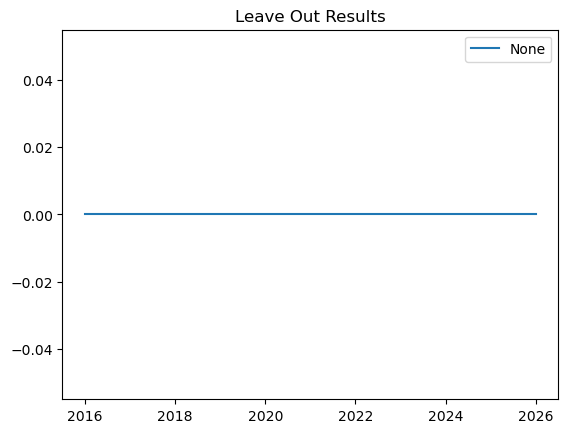

  Metric  RAGU_diff
0   None        0.0


In [25]:
leave_out_results_dict = dict()
waterfall_df = pd.DataFrame()
for leave_out in leave_out_list:
    RAGU_diff = np.abs(all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score).mean()
    waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    leave_out_results_dict[leave_out] = RAGU_diff
    plt.plot(all_leave_out_df.loc['None'].vintage.apply(vintage_to_float), all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score, label=leave_out)
plt.title("Leave Out Results")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()
print(pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff'))
waterfall_df.index = all_leave_out_df.loc['None'].vintage
#waterfall_df

In [26]:
leave_out_df#[np.array(leave_out_df.reset_index().vintage.apply(vintage_to_float)>=2022)]

,index,amt_financed_x,loss_multiplier,recovery_unadjusted_multiplier,ltv,bbvalue,ltv_realization_factor,recovery_100_ltv_multiplier,recovery_multiplier,model_score,amt_financed_y,est_unit_loss,unit_loss_score,ms_original,baselined_recovery,baselined_unadjusted_recovery,baselined_100_ltv_recovery,ms_gla,ms_exclude_ltv,only_recovery_ragu,ms_100_ltv,ragu_score,leave_out
vintage,,,,,,,,,,,,,,,,,,,,,,,
2016 Q1,non_kmxent,95592563.05,NaN,0.54595,2.001846,NaN,NaN,0.0,0.0,NaN,NaN,0.5,129.043433,128.544989,0.0,1.011018,0.0,129.043433,129.431558,0.388125,129.043433,129.043433,None
2016 Q2,non_kmxent,81034666.13,NaN,0.548129,1.983602,NaN,NaN,0.0,0.0,NaN,NaN,0.5,130.632363,130.131358,0.0,1.015055,0.0,130.632363,131.171341,0.538978,130.632363,130.632363,None
2016 Q3,non_kmxent,81719531.04,NaN,0.551976,1.963441,NaN,NaN,0.0,0.0,NaN,NaN,0.5,131.832039,131.347053,0.0,1.022178,0.0,131.832039,132.638962,0.806923,131.832039,131.832039,None
2016 Q4,non_kmxent,75225910.35,NaN,0.553801,1.997902,NaN,NaN,0.0,0.0,NaN,NaN,0.5,132.117127,131.417818,0.0,1.025556,0.0,132.117127,133.052067,0.93494,132.117127,132.117127,None
2017 Q1,non_kmxent,91520948.93,NaN,0.555877,1.972682,NaN,NaN,0.0,0.0,NaN,NaN,0.5,133.033411,132.060104,0.0,1.029402,0.0,133.033411,134.120563,1.087152,133.033411,133.033411,None
2017 Q2,non_kmxent,88289305.27,NaN,0.561482,1.909907,NaN,NaN,0.0,0.0,NaN,NaN,0.5,133.92372,133.041005,0.0,1.039781,0.0,133.92372,135.419385,1.495665,133.92372,133.92372,None
2017 Q3,non_kmxent,80791149.23,NaN,0.563159,1.937234,NaN,NaN,0.0,0.0,NaN,NaN,0.5,133.723422,132.725462,0.0,1.042887,0.0,133.723422,135.338296,1.614875,133.723422,133.723422,None
2017 Q4,non_kmxent,86921625.51,NaN,0.565694,1.917064,NaN,NaN,0.0,0.0,NaN,NaN,0.5,133.901355,132.936161,0.0,1.047582,0.0,133.901355,135.703444,1.80209,133.901355,133.901355,None
2018 Q1,non_kmxent,113452723.11,NaN,0.55953,1.932294,NaN,NaN,0.0,0.0,NaN,NaN,0.5,133.59045,132.44486,0.0,1.036168,0.0,133.59045,134.942175,1.351725,133.59045,133.59045,None


C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\3882856466.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1, 1))


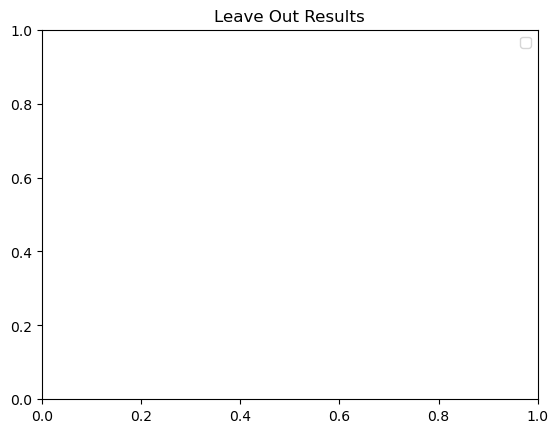

,Metric,RAGU_diff


In [27]:
leave_out_results_dict = dict()
for leave_out in leave_out_list:
    plt_df = waterfall_df[np.array(waterfall_df.reset_index().vintage.apply(vintage_to_float)>=2020)].reset_index()
    if (np.abs(plt_df['None'] - plt_df[leave_out])).mean() < 0.05:
        continue
    plt.plot(plt_df.vintage.apply(vintage_to_float), smooth(np.abs(plt_df['None'] - plt_df[leave_out])), label=leave_out)
    leave_out_results_dict[leave_out] = np.abs(plt_df['None'] - plt_df[leave_out]).mean()
plt.title("Leave Out Results")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()
pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff')

In [28]:
store_pickle(vintages_dict, 'vintages_dict_pickle')

In [29]:
pd.Series(leave_out_results_dict).reset_index().rename(columns={0:'RAGU_diff', 'index':'Metric'}).sort_values('RAGU_diff')

,Metric,RAGU_diff


# Export results to an Excel for manual inputs

In [30]:
import openpyxl
import pyodbc
import warnings
import pandas as pd
import datetime
import numpy as np
import re
import os
import copy

In [31]:
def excel_cell_to_index(cell_name):
    """
    Converts a cell name to its index; for example, 'B2' becomes (2, 2), since B is the second letter of the alphabet.
    """
    # Extract the column part from the cell name
    col_str = ''.join(filter(str.isalpha, cell_name)).upper()
    # Convert column letters to column index
    col_index = 0
    for i, char in enumerate(col_str):
        col_index = col_index * 26 + (ord(char) - ord('A')) + 1
    # Extract the row part from the cell name
    row_str = ''.join(filter(str.isdigit, cell_name))
    # Convert row string to row index
    row_index = int(row_str)
    return row_index, col_index
def overwrite_values(df, start_cell, worksheet):
    """
    Overwrites values in the given worksheet with the values in the given DataFrame, starting at the given cell name start_cell.
    """
    # Get the size of the DataFrame
    num_rows, num_cols = df.shape
    # Get starting cell indices
    start_cell_row, start_cell_col = excel_cell_to_index(start_cell)
    # Replace the data in the worksheet with the DataFrame
    for row in range(num_rows):
        for col in range(num_cols):
            cell = worksheet.cell(row=row+start_cell_row, column=col+start_cell_col)
            cell.value = df.iloc[row, col]
    return worksheet
def read_excel_selection(start_cell, end_cell, worksheet):
    """
    Converts a section of the worksheet to a Pandas DataFrame.
    """
    start_row, start_col = excel_cell_to_index(start_cell)
    end_row, end_col = excel_cell_to_index(end_cell)
    # Read data from the selected range into a list of lists
    data = []
    for row in range(start_row, end_row + 1):
        row_data = []
        for col in range(start_col, end_col + 1):
            cell = worksheet.cell(row=row, column=col)
            row_data.append(cell.value)
        data.append(row_data)
    return pd.DataFrame(data)
# This function returns the value contained within a given cell
excel_lookup = lambda cell: workbook[re.search(r'=(.*?)!', cell.value).group(1)][re.search(r'!(.*)', cell.value).group(1)]

In [32]:
# Be sure to rerun this code after hitting ctrl+s in the Excel document.
workbook = openpyxl.load_workbook('new_recovery_ragu.xlsx')

# Save Data Tables

### NonKMXENT

In [33]:
worksheet = workbook[f'Data Tables ({granularity.upper()})']

In [34]:
worksheet

<Worksheet "Data Tables (Q)">

In [35]:
for lob, cell in zip(('AN', 'FRN', 'STG', 'non_kmxent'), ('B2', 'B20', 'B29', 'B47')):
    result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
    result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df = result_yearly_df.drop('amt_financed_x')
    for year in range(2016, 2020):
        year = str(year)
        metric_dict = dict()
        if granularity=='q':
            vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)]
        elif granularity == 'm':
            vintages_in_year = [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
        
        for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
            metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
        result_yearly_df[year] = pd.Series(metric_dict)
    result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
    result_yearly_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
    full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
    differences_df = full_result_df.copy()
    differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    worksheet = overwrite_values(xlsx_df, cell, worksheet)

In [36]:
correct_vintage_order = list(xlsx_df.columns)

### ENT, FLD

In [37]:
for lob, cell in zip(('ENT', 'FLD'), ('F38', 'F11')):
    result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
    result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
    result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
    result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
    full_result_df = result_df.copy()
    differences_df = full_result_df.copy()
    differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
    differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
    differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
    differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
    differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
    differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
    differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
    xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
    worksheet = overwrite_values(xlsx_df, cell, worksheet)

In [38]:
# for lob, cell in zip(('ENT', 'FLD'), ('F38', 'F11')):
#     result_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']].reset_index(drop=True).set_index('vintage').T.copy()
#     result_df = pd.concat([result_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
#     result_df.index = ['FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
#     result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
#     full_result_df = result_df.copy()
#     differences_df = full_result_df.copy()
#     differences_df.loc['FRN 3.1 Score'] = full_result_df.loc['FRN 3.1 Score'] - full_result_df.loc['Contract Model Score']
#     differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['FRN 3.1 Score']
#     differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
#     differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
#     differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
#     differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
#     differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
#     xlsx_df = differences_df.T[['Contract Model Score', 'FRN 3.1 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T

In [39]:
# scratch = all_df_no_dropout.loc['ENT'][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv']]#.reset_index(drop=True).set_index('vintage').T.copy()
# scratch.to_csv("scratch.csv")

### KMX

In [40]:
lob = 'KMX'
result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
result_df = result_yearly_df.drop('amt_financed_x')
for year in range(2016, 2020):
    year = str(year)
    metric_dict = dict()
    vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)] if granularity=='q' else [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
    for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
        metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
    result_yearly_df[year] = pd.Series(metric_dict)
result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
result_yearly_df.index = ['Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df.index = ['Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
differences_df = full_result_df.copy()
differences_df.loc['Mountain3 Score'] = full_result_df.loc['Mountain3 Score'] - full_result_df.loc['Contract Model Score']
differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Mountain3 Score']
differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
xlsx_df = differences_df.T[['Contract Model Score', 'Mountain3 Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
xlsx_df = xlsx_df[correct_vintage_order]
print(xlsx_df)
worksheet = overwrite_values(xlsx_df, 'B56', worksheet)

vintage                                     2016        2017        2018  \
Contract Model Score                  136.564612  139.100479  137.779779   
Mountain3 Score                         0.000000    0.000000    0.000000   
Gross Loss Adjustments                  4.744682    4.803684    4.605444   
Recovery Adjustments (Excluding LTV)    1.616356    0.526805    0.519609   
LTV Adjustments                        -1.616356   -0.526805   -0.519609   
RAGU Score                            141.309294  143.904164  142.385223   
LTV                                     1.586932    1.572015    1.585633   

vintage                                     2019     2020 Q1     2020 Q2  \
Contract Model Score                  136.877822  135.863322  138.372042   
Mountain3 Score                         0.000000    0.000000    0.000000   
Gross Loss Adjustments                  4.617798    4.495193    4.552200   
Recovery Adjustments (Excluding LTV)    0.444795   -0.159289    0.243695   
LTV Adjustm

### POS

In [41]:
lob = 'POS'
result_yearly_df = all_df_no_dropout.loc[lob][['vintage', 'ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x']].reset_index(drop=True).set_index('vintage').T.copy()
result_yearly_df = pd.concat([result_yearly_df, original_model_scores[original_model_scores.lob==lob].drop(columns=['lob', 'amt_financed']).set_index(['vintage']).T.rename({'model_score':'contract_model_score'})])
result_df = result_yearly_df.drop('amt_financed_x')
for year in range(2016, 2020):
    year = str(year)
    metric_dict = dict()
    vintages_in_year = [year + ' Q' + str(i) for i in range(1, 5)] if granularity=='q' else [year + ' M' + str(i).zfill(2) for i in range(1, 13)]
    for metric in ['ms_original', 'ms_gla', 'ms_exclude_ltv', 'ms_100_ltv', 'ragu_score', 'ltv', 'amt_financed_x', 'contract_model_score']:
        metric_dict[metric] = (result_yearly_df[vintages_in_year].T[metric] * result_yearly_df[vintages_in_year].T.amt_financed_x).sum() / result_yearly_df[vintages_in_year].T.amt_financed_x.sum()
    result_yearly_df[year] = pd.Series(metric_dict)
result_yearly_df = result_yearly_df[[str(y) for y in range(2016, 2020)]].drop('amt_financed_x')
result_yearly_df.index = ['Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df.index = ['Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'Haircut on LTV Adjustments', 'LTV', 'Contract Model Score']
result_df = result_df.T.reset_index()[result_df.T.reset_index().vintage.apply(vintage_to_float) >= 2020].set_index('vintage').T
full_result_df = pd.concat([result_yearly_df.T, result_df.T]).T
differences_df = full_result_df.copy()
differences_df.loc['Modern Score'] = full_result_df.loc['Modern Score'] - full_result_df.loc['Contract Model Score']
differences_df.loc['Gross Loss Adjustments'] = full_result_df.loc['Gross Loss Adjustments'] - full_result_df.loc['Modern Score']
differences_df.loc['Recovery Adjustments (Excluding LTV)'] = full_result_df.loc['Recovery Adjustments (Excluding LTV)'] - full_result_df.loc['Gross Loss Adjustments']
differences_df.loc['LTV Adjustments'] = full_result_df.loc['LTV Adjustments'] - full_result_df.loc['Recovery Adjustments (Excluding LTV)']
differences_df.loc['Haircut on LTV Adjustments'] = full_result_df.loc['Haircut on LTV Adjustments'] - full_result_df.loc['LTV Adjustments']
differences_df.loc['RAGU Score'] = full_result_df.loc['LTV Adjustments'].copy()
differences_df.loc['RAGU Score (Adjusted)'] = full_result_df.loc['Haircut on LTV Adjustments'].copy()
xlsx_df = differences_df.T[['Contract Model Score', 'Modern Score', 'Gross Loss Adjustments', 'Recovery Adjustments (Excluding LTV)', 'LTV Adjustments', 'RAGU Score', 'LTV']].T
worksheet = overwrite_values(xlsx_df, 'B65', worksheet)

# Distribution Data

In [42]:
with pyodbc.connect("DSN=Redshift_prod_new") as conn:
    with open("distribution_query_temp.txt", "r") as file:
        temp_table_queries = file.read()
        conn.execute(temp_table_queries.strip())
        distribution_df = run_sql('distribution_query_current.txt', connection=conn)
distribution_df  = distribution_df.pivot(index = 'roa_dealer_group',columns = 'vintage', values = 'distribution')

worksheet = worksheet = workbook['distribution_rolledup']
worksheet = overwrite_values(distribution_df,'B3', worksheet)

In [43]:
distribution_df.to_csv('dist_df.csv')

# $t_{-1}$ Table

In [44]:
worksheet = workbook['t-1 Data Table']
run_query = False
if run_query or run_every_query:
    t_1_table = run_sql('select * from sandbox.t_1', filename_is_query=True)
    store_pickle(t_1_table, 't_1_table_pickle')
else:
    t_1_table = get_pickle('t_1_table_pickle')
latest_t_1 = pd.DataFrame(columns=t_1_table.columns)
for lob in t_1_table.roa_dealer_group.unique():
    latest_t_1 = pd.concat([latest_t_1, t_1_table[t_1_table['lookup']==(lob+str(t_1_table[t_1_table.roa_dealer_group==lob].rowid.max()))]])
latest_t_1 = latest_t_1.sort_values('lookup').set_index('roa_dealer_group').loc[['AN', 'ENT', 'FLD', 'FRN', 'KMX', 'STG']]
worksheet = overwrite_values(latest_t_1, 'B2', worksheet)

C:\Users\ahmed.ali\AppData\Local\Temp\ipykernel_44076\1305636891.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  latest_t_1 = pd.concat([latest_t_1, t_1_table[t_1_table['lookup']==(lob+str(t_1_table[t_1_table.roa_dealer_group==lob].rowid.max()))]])


# Put Leave Out Analysis Waterfalls in Excel

In [45]:
worksheet = workbook['Waterfall Tables']
waterfall_df_dict = dict()
for lob, cell, lob_type in zip(['AN', 'FRN', 'STG', 'FLD', 'KMX', 'ENT'], 
                     ['B3', 'B48', 'B92', 'B135', 'B190', 'B164'],
                     ['non_kmxent']*4+['KMX', 'ENT']):
    all_leave_out_df = pd.DataFrame()
    for leave_out in leave_out_list:
        leave_out_df = pd.DataFrame()
        for i in full_df_list_dict_dict[leave_out][lob_type]:
            if (lob=='FLD' and 'FLD' not in i.index) or (lob=='ENT' and 'ENT' not in i.index):
                continue
            leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc[lob]).T])
        leave_out_df['leave_out'] = leave_out
        leave_out_df = leave_out_df.reset_index().set_index('vintage')
        all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
    all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

    waterfall_df = pd.DataFrame()
    for leave_out in leave_out_list:
        waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    waterfall_df.index = all_leave_out_df.loc['None'].vintage
    waterfall_df_dict[lob] = waterfall_df
    worksheet = overwrite_values(waterfall_df, cell, worksheet)

In [46]:
for lob, lob_type in zip(['FLD'], 
                        ['non_kmxent']):
    all_leave_out_df = pd.DataFrame()
    for leave_out in leave_out_list:
        leave_out_df = pd.DataFrame()
        for i in full_df_list_dict_dict[leave_out][lob_type]:
            if (lob=='FLD' and 'FLD' not in i.index) or (lob=='ENT' and 'ENT' not in i.index):
                continue
            leave_out_df = pd.concat([leave_out_df, pd.DataFrame(i.loc[lob]).T])
        leave_out_df['leave_out'] = leave_out
        leave_out_df = leave_out_df.reset_index().set_index('vintage')
        all_leave_out_df = pd.concat([all_leave_out_df, leave_out_df])
    all_leave_out_df = all_leave_out_df.reset_index().set_index('leave_out')

    waterfall_df = pd.DataFrame()
    for leave_out in leave_out_list:
        waterfall_df[leave_out] = all_leave_out_df.loc['None'].reset_index().ragu_score - all_leave_out_df.loc[leave_out].reset_index().ragu_score
    waterfall_df.index = all_leave_out_df.loc['None'].vintage
    waterfall_df_dict[lob] = waterfall_df
    waterfall_df.to_csv('waterfallFLD.csv')

In [47]:
workbook.save('cursor_ragu.xlsx')

In [48]:
mmi_lookup_df = pd.read_csv('../../Downloads/mmi_index_2019seasonality.csv').rename(columns={'mmi_2019_seasonality_index':'mmi'})
mmi_lookup_df['month'] = mmi_lookup_df.month_start.astype(str).str[:4] + '-' + mmi_lookup_df.month_start.astype(str).str[4:6]
mmi_lookup_df = mmi_lookup_df.drop(columns='month_start')
mmi_lookup_df

FileNotFoundError: [Errno 2] No such file or directory: '../../Downloads/mmi_index_2019seasonality.csv'

In [ ]:
pd.__version__

In [ ]:
pd.get_option('mode.copy_on_write')

In [ ]:
all_leave_out_df

In [ ]:
scratch = ula_df_total.loc[(ula_df_total['lob']=='KMX') & (ula_df_total['vintage']=='2025 M02')]
scratch.head()